# LIBRARY

In [1]:
import geopandas as gpd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import shapely.geometry as sgeom
import xarray as xr
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# HELPER

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_line_chart_tahunan(ds, var_name, mask_2d, judul, ylabel, warna_garis='teal', metode='mean'):
    """
    Menampilkan Line Chart untuk nilai akumulasi tahunan (2014, 2015, ..., 2024).
    Parameter 'metode': 
      - 'sum'  : untuk menghitung total nilai sepanjang tahun (cocok untuk Klorofil-a)
      - 'mean' : untuk menghitung rata-rata nilai sepanjang tahun (cocok untuk SST)
    """
    print(f"🔄 Menghitung rata-rata spasial area WPP per waktu untuk '{var_name}'...")
    # 1. Hitung rata-rata spasial WPP untuk setiap langkah waktu terlebih dahulu
    data_spatial_mean = ds[var_name].where(mask_2d).mean(dim=['lat', 'lon'], skipna=True)
    
    print(f"📅 Melakukan akumulasi tahunan menggunakan metode '{metode}'...")
    # 2. Agregasi data dari per 8-hari menjadi per tahun (time.year)
    if metode.lower() == 'sum':
        data_tahunan = data_spatial_mean.groupby('time.year').sum(skipna=True)
    else:
        data_tahunan = data_spatial_mean.groupby('time.year').mean(skipna=True)
        
    # Extract tahun dan nilainya
    tahun = data_tahunan['year'].values
    nilai = data_tahunan.values
    
    # 3. Pengondisian jika ada nilai NaN
    valid_idx = np.isfinite(nilai)
    tahun_valid = tahun[valid_idx]
    nilai_valid = nilai[valid_idx]
    
    print("📊 Menggambar Line Chart Tahunan...")
    fig, ax = plt.subplots(figsize=(10, 5))
    
    # 4. Plot Garis dan Titik (Marker) agar nilai per tahun terlihat jelas
    ax.plot(tahun_valid, nilai_valid, color=warna_garis, linewidth=2.5, 
            marker='o', markersize=8, markerfacecolor='crimson', markeredgecolor='white',
            label=f'Nilai Tahunan ({metode.upper()})')
    
    # 5. Kustomisasi Estetika Grafis
    ax.set_title(judul, fontsize=15, fontweight='bold', pad=15)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel('Tahun', fontsize=12)
    
    # Pastikan sumbu X hanya menampilkan angka tahun bulat (bukan desimal)
    ax.set_xticks(tahun_valid)
    ax.set_xticklabels(tahun_valid, rotation=45)
    
    # Menampilkan nilai angka tepat di atas setiap titik marker (Anotasi)
    for t, n in zip(tahun_valid, nilai_valid):
        ax.annotate(f'{n:.2f}', (t, n), textcoords="offset points", 
                    xytext=(0,10), ha='center', fontsize=9, fontweight='bold', color='#333333')
    
    # Grid dan batasan sumbu X
    ax.grid(True, linestyle='--', color='lightgray', alpha=0.7)
    ax.set_xlim([tahun_valid.min() - 0.5, tahun_valid.max() + 0.5])
    
    # Bersihkan bingkai tepi atas dan kanan
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('gray')
    ax.spines['bottom'].set_color('gray')
    
    plt.tight_layout()
    plt.show()
    print("✅ Line Chart Tahunan berhasil dirender!\n")

In [3]:
def plot_distribusi_bulanan(ds, var_name, mask_2d, judul, ylabel, warna='steelblue', tampilkan_outlier=True):
    """
    Menampilkan Boxplot Distribusi Bulanan (Januari - Desember) dari seluruh piksel area WPP.
    Meniru gaya visual Seaborn/Pandas klasik dengan judul dan label Y yang bisa dikustomisasi.
    """
    print(f"🔄 Mengekstrak dan mengelompokkan piksel valid per bulan untuk '{var_name}'...")
    
    data_per_bulan = []
    
    # Mengelompokkan seluruh data 3D berdasarkan bulan kalender (1 - 12)
    grup_bulan = ds[var_name].groupby('time.month')
    
    for m in range(1, 13):
        if m in grup_bulan.groups:
            # Ekstrak data bulan ke-m, potong dengan mask, lalu buang NaN
            data_3d_bulan = grup_bulan[m].values
            data_inside = data_3d_bulan[:, mask_2d]
            data_valid = data_inside[np.isfinite(data_inside)]
            data_per_bulan.append(data_valid)
        else:
            data_per_bulan.append(np.array([])) # Jaga-jaga jika ada bulan yang kosong
            
    print("📊 Menggambar Boxplot Distribusi Bulanan...")
    
    # Siapkan kanvas
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Render boxplot (dengan label sumbu X berupa angka 1 - 12)
    box = ax.boxplot(data_per_bulan, vert=True, patch_artist=True, 
                     showfliers=tampilkan_outlier, labels=range(1, 13), widths=0.6)
    
    # ==========================================
    # KUSTOMISASI ESTETIKA (Gaya seperti gambar referensi)
    # ==========================================
    for patch in box['boxes']:
        patch.set_facecolor(warna)
        patch.set_alpha(0.9)
        patch.set_edgecolor('#333333')
        patch.set_linewidth(1.2)
        
    for median in box['medians']:
        median.set_color('#333333') # Garis tengah berwarna gelap
        median.set_linewidth(1.5)
        
    for whisker in box['whiskers']:
        whisker.set_color('#333333')
        whisker.set_linewidth(1.2)
        
    for cap in box['caps']:
        cap.set_color('#333333')
        cap.set_linewidth(1.2)
        
    # Kustomisasi bentuk titik outlier
    if tampilkan_outlier:
        for flier in box['fliers']:
            flier.set(marker='o', color='black', alpha=0.4, markersize=4, markeredgecolor='black')
            
    # ==========================================
    # MODIFIKASI: Desain Latar, Judul, dan Sumbu
    # ==========================================
    ax.set_title(judul, fontsize=14, pad=15)
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # Grid horizontal yang halus (mirip gambar referensi)
    ax.grid(axis='y', linestyle='-', color='lightgray', alpha=0.7)
    ax.set_axisbelow(True) # Memastikan grid berada di belakang kotak
    
    # Hilangkan garis tepi atas dan kanan agar terlihat bersih
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('lightgray')
    ax.spines['bottom'].set_color('lightgray')
    
    plt.tight_layout()
    plt.show()
    print("✅ Plot berhasil dirender!\n")

In [4]:
# data deskripsi
def deskripsi_data_wpp(ds, var_name, mask_2d):
    """
    Fungsi untuk menampilkan statistik deskriptif dari suatu variabel 
    (misal: 'chlor_a' atau 'sst') khusus di area dalam WPP 572.
    """
    # 1. Ekstrak data 3D dan potong sesuai mask_2d
    data_3d = ds[var_name].values
    data_inside = data_3d[:, mask_2d]  
    
    # 2. Ambil hanya nilai yang valid (bukan NaN)
    data_valid = data_inside[np.isfinite(data_inside)]
    
    # Proteksi jika seluruh data ternyata NaN
    if len(data_valid) == 0:
        return pd.DataFrame({"Pesan": [f"⚠️ Tidak ada data valid untuk {var_name}"]})
        
    # 3. Perhitungan Statistik
    mean_val = np.mean(data_valid)
    min_val = np.min(data_valid)
    max_val = np.max(data_valid)
    range_val = max_val - min_val
    std_val = np.std(data_valid) # Tambahan Standar Deviasi
    q1 = np.percentile(data_valid, 25)
    median = np.percentile(data_valid, 50)
    q3 = np.percentile(data_valid, 75)
    
    # 4. Menyusun DataFrame
    df_desc = pd.DataFrame({
        'Statistik': [
            'Rata-rata', 
            'Std Deviasi', 
            'Minimum', 
            '25% (Q1)', 
            'Median', 
            '75% (Q3)', 
            'Maximum', 
            'Range'
        ],
        f'Nilai_{var_name}': [
            mean_val, 
            std_val, 
            min_val, 
            q1, 
            median, 
            q3, 
            max_val, 
            range_val
        ]
    })
    
    # 5. Set index agar tampilan transpose (.T) terlihat sangat rapi sebagai header tabel
    df_desc.set_index('Statistik', inplace=True)
    
    # Mengembalikan DataFrame yang sudah di-transpose dan dibulatkan 3 angka di belakang koma
    return df_desc.T.round(3)

In [5]:
# cek kebagusan hasil handling missval
def investigasi(ds_asli, ds_clean, var_name, mask_2d, batas_ekstrem=100):
    """
    Fungsi untuk menyelidiki anomali (outlier) hasil pengisian missing value.
    Menampilkan daftar tanggal kejadian anomali yang disandingkan langsung 
    dengan persentase missing value (awan) pada data aslinya.
    """
    print(f"🔍 --- MEMULAI INVESTIGASI ANOMALI '{var_name}' (> {batas_ekstrem}) ---")
    
    # 1. Ekstrak data matriks
    clean_inside = ds_clean[var_name].values[:, mask_2d]
    
    # 2. Hitung statistik umum untuk area valid
    valid_clean = clean_inside[np.isfinite(clean_inside)]
    jumlah_outlier = np.sum(valid_clean > batas_ekstrem)
    total_data = len(valid_clean)
    
    if total_data == 0:
        print("⚠️ Tidak ada data valid untuk dievaluasi.")
        return
        
    persentase = (jumlah_outlier / total_data) * 100
    
    print(f"Total piksel valid WPP    : {total_data:,} piksel")
    print(f"Jumlah piksel ekstrem     : {jumlah_outlier:,} piksel")
    print(f"Persentase piksel ekstrem : {persentase:.6f} %\n")
    
    # =====================================================================
    # 3. LACAK TANGGAL OUTLIER & KORELASIKAN DENGAN AWAN ASLI
    # =====================================================================
    if jumlah_outlier > 0:
        print("🗓️ --- RINCIAN KEJADIAN OUTLIER & TUTUPAN AWAN ---")
        
        # Buat mask 2D untuk lokasi ekstrem
        mask_outlier_2d = (clean_inside > batas_ekstrem)
        
        # Hitung jumlah titik ekstrem per waktu (sumbu baris)
        outlier_per_waktu = np.sum(mask_outlier_2d, axis=1)
        
        # Ambil indeks (posisi baris) yang memiliki anomali
        indeks_waktu_outlier = np.where(outlier_per_waktu > 0)[0]
        
        # Iterasi pada setiap indeks yang bermasalah
        for idx in indeks_waktu_outlier:
            # Ambil tanggal dan jumlah ekstrem
            waktu_kejadian = ds_clean['time'].values[idx]
            t_str = np.datetime_as_string(waktu_kejadian, unit='D')
            jml_ekstrem = outlier_per_waktu[idx]
            
            # CEK DATA ASLI: Gunakan indeks 'idx' yang sama untuk menarik data mentah
            raw_inside = ds_asli[var_name].values[idx, mask_2d]
            jml_nan = np.isnan(raw_inside).sum()
            persentase_nan = (jml_nan / len(raw_inside)) * 100
            
            # Format cetak rapi dengan tabulasi dinamis
            print(f"-> {t_str} | Outlier: {jml_ekstrem:<5} piksel | Tutupan Awan Asli: {persentase_nan:>6.2f}%")
            
    else:
        print("✅ Data sangat sehat. Tidak ditemukan outlier ekstrem pada rentang waktu mana pun.")
        
    print("-" * 60)

In [6]:
# linechart
def plot_tren_waktu(ds, var_name, judul="Tren Waktu Rata-rata Spasial", ylabel="Nilai", warna='blue'):
    rata_rata_spasial = ds[var_name].mean(dim=['lat', 'lon'], skipna=True)
    
    plt.figure(figsize=(14, 5))
    
    waktu = rata_rata_spasial['time'].values
    nilai = rata_rata_spasial.values
    
    plt.plot(waktu, nilai, color=warna, marker='o', markersize=3, linestyle='-', linewidth=1.5, alpha=0.8)
    
    padding = np.timedelta64(30, 'D')
    plt.xlim(waktu.min() - padding, waktu.max() + padding)
    
    # Kustomisasi Label Sumbu X (Hanya Januari dan Juni)
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    plt.gca().xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7])) 
    
    plt.gcf().autofmt_xdate()
    
    plt.title(judul, fontsize=14, fontweight='bold')
    plt.xlabel('Waktu (Komposit 8-Day)', fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.show()

In [7]:
def plot_scatter_sst_chl_sinkron(ds_chl, ds_sst, var_chl='chlor_a', var_sst='sst', mask_2d=None):
    """
    Fungsi scatter plot yang otomatis menyelaraskan (align) dimensi waktu 
    antara dataset Chl-a dan SST menggunakan teknik Inner Join.
    """
    print("🔄 Langkah 1: Menghitung rata-rata spasial WPP 572 per waktu...")
    # Hitung rata-rata spasial (koordinat lat & lon dilebur, menyisakan dimensi 'time')
    chl_mean_time = ds_chl[var_chl].where(mask_2d).mean(dim=['lat', 'lon'], skipna=True)
    sst_mean_time = ds_sst[var_sst].where(mask_2d).mean(dim=['lat', 'lon'], skipna=True)
    
    print(f"📊 Ukuran waktu awal  -> Chl-a: {chl_mean_time.shape[0]} | SST: {sst_mean_time.shape[0]}")
    
    # =====================================================================
    # SOLUSI UTAMA: SELARASKAN WAKTU DENGAN INNER JOIN
    # =====================================================================
    print("✂️ Langkah 2: Menyinkronkan tanggal (membuang waktu yang tidak berpasangan)...")
    chl_aligned, sst_aligned = xr.align(chl_mean_time, sst_mean_time, join='inner')
    
    print(f"🎯 Ukuran waktu akhir -> Chl-a: {chl_aligned.shape[0]} | SST: {sst_aligned.shape[0]}")
    
    # 3. Ekstrak nilai matriks ke numpy array
    chl_vals = chl_aligned.values
    sst_vals = sst_aligned.values
    
    # 4. Pengaman sisa NaN (jika ada minggu yang seluruh lautnya tertutup awan murni)
    valid_idx = np.isfinite(chl_vals) & np.isfinite(sst_vals)
    x_data = sst_vals[valid_idx]
    y_data = chl_vals[valid_idx]
    
    # 5. Hitung Koefisien Korelasi Pearson (r)
    korelasi = np.corrcoef(x_data, y_data)[0, 1]
    
    # 6. Pembuatan Grafik Scatter Plot
    print("📈 Langkah 3: Menggambar Scatter Plot & Garis Regresi...")
    plt.figure(figsize=(9, 7))
    
    sns.regplot(
        x=x_data, 
        y=y_data, 
        scatter_kws={'alpha': 0.6, 'color': 'teal', 'edgecolor': 'w', 's': 50}, 
        line_kws={'color': 'crimson', 'linewidth': 2.5}
    )
    
    # Desain Tampilan
    plt.title(f'Scatter Plot Korelasi Rata-rata SST vs Klorofil-a (Waktu Sinkron)\nArea WPP 572 (Korelasi Pearson $r$ = {korelasi:.3f})', 
              fontsize=13, fontweight='bold', pad=15)
    
    plt.xlabel('Sea Surface Temperature / SST (°C)', fontsize=12)
    plt.ylabel('Klorofil-a (mg/m³)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

In [8]:
def plot_klimatologi_final(ds, var_name, cbar_label, judul, cmap_name='viridis', 
                           tahun_mulai='2014-01-01', tahun_akhir='2024-12-31', 
                           percentile_max=95):
    """
    Fungsi generik plot Klimatologi Bulanan:
    - Label bulan di dalam kotak (Kanan Atas)
    - Grid/garis bantu putus-putus
    - Label Longitude & Latitude di setiap plot
    - Bisa untuk Klorofil-a maupun SST
    """
    # 1. Potong waktu dan hitung Rata-rata Bulanan
    ds_subset = ds.sel(time=slice(tahun_mulai, tahun_akhir))
    print(f"🔄 Menghitung rata-rata klimatologi ({tahun_mulai[:4]}-{tahun_akhir[:4]}) untuk '{var_name}'...")
    klimatologi_bulanan = ds_subset[var_name].groupby('time.month').mean(dim='time', skipna=True)
    
    # 2. Canvas TANPA sharex/sharey agar sumbu muncul di semua kotak
    fig, axes = plt.subplots(nrows=4, ncols=3, figsize=(15,20))
    axes = axes.flatten()
    
    nama_bulan = ['Jan', 'Feb', 'Mar', 'Apr', 'Mei', 'Jun', 
                  'Jul', 'Ags', 'Sep', 'Okt', 'Nov', 'Des']
    
    # 3. Pengaturan Warna
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad('white') # Daratan putih bersih
    
    vmin = np.nanmin(klimatologi_bulanan.values)
    vmax = np.nanpercentile(klimatologi_bulanan.values, percentile_max)
    
    print("📊 Menggambar 12 plot heatmap...")
    for i in range(12):
        ax = axes[i]
        data_bulan = klimatologi_bulanan.sel(month=i+1)
        
        # A. Plot Heatmap Dasar (zorder=1 ditaruh di bawah)
        img = data_bulan.plot.pcolormesh(
            ax=ax, cmap=cmap, vmin=vmin, vmax=vmax, add_colorbar=False, zorder=1
        )
        
        # B. Garis Bantu (Grid) putus-putus (zorder=2 agar muncul di atas warna laut)
        ax.grid(True, color='gray', linestyle='--', linewidth=0.5, alpha=0.6, zorder=2)
        
        # C. Teks Box Bulan di Kanan Atas (Gaya Gambar Lama)
        ax.text(0.92, 0.92, nama_bulan[i], transform=ax.transAxes,
                fontsize=16, fontweight='bold', color='black',
                ha='right', va='top', zorder=3,
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='square,pad=0.3', linewidth=1.5))
        
        # D. Desain Kotak
        ax.set_title('') # Hapus title bawaan yang di atas
        ax.set_aspect('equal', adjustable='box')
        
        # E. Tampilkan Label Sumbu di SETIAP plot
        ax.set_xlabel('Longitude', fontsize=11)
        ax.set_ylabel('Latitude', fontsize=11)

    # 4. Padding/Jarak Antar Plot (h_pad=3.0 memberi jarak vertikal ekstra agar label tidak mepet)
    plt.tight_layout(rect=[0, 0, 0.90, 0.95], h_pad=0, w_pad=0.5)
    
    # 5. Colorbar Global di Sebelah Kanan
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7]) 
    cbar = fig.colorbar(img, cax=cbar_ax, orientation='vertical')
    cbar.set_label(cbar_label, fontsize=15, fontweight='bold')
    
    # 6. Judul Keseluruhan
    plt.suptitle(judul, fontsize=22, fontweight='bold')
    
    plt.show()
    print("✅ Plot berhasil dirender!\n")

In [9]:
def plot_distribusi_data(ds, var_name, mask_2d, warna='teal', satuan='mg/m³'):
    """
    Menampilkan Histogram dan Boxplot vertikal bersisian.
    Badan boxplot dibuat lebih ramping.
    """
    print(f"🔄 Mengekstrak seluruh piksel valid untuk '{var_name}'...")
    
    # 1. Ekstrak data 3D dan potong sesuai mask_2d
    data_3d = ds[var_name].values
    data_inside = data_3d[:, mask_2d]  
    
    # 2. Ambil hanya nilai yang valid (Hapus NaN)
    data_valid = data_inside[np.isfinite(data_inside)]
    
    print(f"📊 Menyiapkan visualisasi untuk {len(data_valid):,} titik data...")
    
    # Setup Canvas
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6), gridspec_kw={'width_ratios': [2, 1]})
    
    # ==========================================
    # --- PLOT 1: HISTOGRAM ---
    # ==========================================
    batas_bawah = np.min(data_valid)
    batas_atas = np.percentile(data_valid, 99)
    
    axes[0].hist(data_valid, bins=50, range=(batas_bawah, batas_atas), 
                 color=warna, edgecolor='black', alpha=0.7)
    
    axes[0].set_title(f'Histogram {var_name.upper()}\n(Ditampilkan hingga Persentil 99%)', fontsize=14, fontweight='bold')
    axes[0].set_xlabel(f'Nilai ({satuan})', fontsize=12)
    axes[0].set_ylabel('Frekuensi (Jumlah Piksel)', fontsize=12)
    axes[0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # ==========================================
    # --- PLOT 2: BOXPLOT VERTIKAL ---
    # ==========================================
    # MODIFIKASI: Parameter widths dikecilkan dari 0.5 menjadi 0.25 agar kotak lebih ramping
    box = axes[1].boxplot(data_valid, vert=True, patch_artist=True, showfliers=False, widths=0.25)
    
    for patch in box['boxes']:
        patch.set_facecolor(warna)
        patch.set_alpha(0.7)
        
    for median in box['medians']:
        median.set_color('crimson')
        median.set_linewidth(2)
        
    axes[1].set_title(f'Boxplot {var_name.upper()}\n(Tanpa visualisasi fliers)', fontsize=14, fontweight='bold')
    axes[1].set_ylabel(f'Nilai ({satuan})', fontsize=12)
    axes[1].set_xticks([1])
    axes[1].set_xticklabels([var_name.upper()], fontsize=12)
    axes[1].grid(axis='y', linestyle='--', alpha=0.7)
    
    # ==========================================
    # FINALISASI TATA LETAK
    # ==========================================
    plt.suptitle(f'Analisis Distribusi Keseluruhan Data: {var_name.upper()}', fontsize=18, fontweight='bold', y=1.05)
    plt.tight_layout(w_pad=2.0)
    
    plt.show()

In [10]:
def plot_acf_pacf_wpp(ds, varname, nlags=156):
    """
    Plot ACF dan PACF dari rata-rata spasial variabel di dalam WPP.
    
    Parameters
    ----------
    ds : xarray.Dataset
        Dataset input.
        
    varname : str
        Nama variabel, misalnya 'chlor_a' atau 'sst'.
        
    nlags : int
        Jumlah lag yang ditampilkan.
    """

    print(f"--- Memulai Plotting ACF & PACF untuk {varname} ---")

    # =====================================================
    # 1. Ambil data dan buat time series rata-rata WPP
    # =====================================================
    data = ds[varname].values

    if data.ndim != 3:
        raise ValueError(
            f"Variabel {varname} harus berdimensi 3D: time, lat, lon."
        )

    if mask_2d.shape != data.shape[1:]:
        raise ValueError(
            f"Shape mask_2d {mask_2d.shape} tidak sama dengan shape spasial data {data.shape[1:]}"
        )

    # Ambil hanya area WPP
    data_wpp = data[:, mask_2d]

    # Rata-rata spasial per waktu
    ts = np.nanmean(data_wpp, axis=1)

    # Buat pandas Series dengan index time jika tersedia
    if "time" in ds.coords:
        ts_series = pd.Series(ts, index=pd.to_datetime(ds["time"].values))
    else:
        ts_series = pd.Series(ts)

    ts_series = ts_series.dropna()

    print(f"Jumlah observasi time series : {len(ts_series)}")
    print(f"Rata-rata                    : {ts_series.mean():.6f}")
    print(f"Standar deviasi              : {ts_series.std():.6f}")

    # =====================================================
    # 2. Plot ACF dan PACF
    # =====================================================
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))

    # Jarak sumbu X
    jarak_sumbu_x = np.arange(0, nlags + 1, 10)

    # ====================
    # Plot ACF
    # ====================
    plot_acf(
        ts_series,
        lags=nlags,
        ax=axes[0],
        color="blue",
        alpha=0.05
    )

    axes[0].set_title(
        f"Autocorrelation Function (ACF)\n{varname}",
        fontsize=14,
        fontweight="bold"
    )
    axes[0].set_xlabel("Lag ke belakang", fontsize=12)
    axes[0].set_ylabel("Korelasi", fontsize=12)
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(jarak_sumbu_x)
    axes[0].tick_params(axis="x", rotation=45)

    # ====================
    # Plot PACF
    # ====================
    plot_pacf(
        ts_series,
        lags=nlags,
        ax=axes[1],
        color="red",
        alpha=0.05,
        method="ywm"
    )

    axes[1].set_title(
        f"Partial Autocorrelation Function (PACF)\n{varname}",
        fontsize=14,
        fontweight="bold"
    )
    axes[1].set_xlabel("Lag ke belakang", fontsize=12)
    axes[1].set_ylabel("Korelasi langsung", fontsize=12)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(jarak_sumbu_x)
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

    return ts_series

In [11]:
def summary_missing(df_miss, nama_data="CHL"):

    # =====================================================
    # Statistik total data
    # =====================================================
    total_valid = df_miss["total_valid"].sum()
    total_missing = df_miss["total_missing"].sum()

    total_data = total_valid + total_missing

    persen_missing = (total_missing / total_data) * 100
    persen_valid = (total_valid / total_data) * 100

    # =====================================================
    # Statistik per timestamp
    # =====================================================
    total_timestamp = len(df_miss)

    n_gt50 = (df_miss["percent_missing"] > 50).sum()
    n_gt75 = (df_miss["percent_missing"] > 75).sum()
    n_gt95 = (df_miss["percent_missing"] > 95).sum()

    pct_gt50 = 100 * n_gt50 / total_timestamp
    pct_gt75 = 100 * n_gt75 / total_timestamp
    pct_gt95 = 100 * n_gt95 / total_timestamp

    # =====================================================
    # Summary dataframe
    # =====================================================
    df_summary = pd.DataFrame({
        "Dataset": [nama_data],
        "Total Timestamp": [total_timestamp],
        "Total Data": [total_data],
        "Total Valid": [total_valid],
        "Total Missing": [total_missing],
        "% Valid": [persen_valid],
        "% Missing": [persen_missing],

        "N Missing >50%": [n_gt50],
        "% Missing >50%": [pct_gt50],

        "N Missing >75%": [n_gt75],
        "% Missing >75%": [pct_gt75],

        "N Missing >95%": [n_gt95],
        "% Missing >95%": [pct_gt95]
    })

    # =====================================================
    # Print ringkasan
    # =====================================================
    print("=" * 70)
    print(f"RINGKASAN MISSING VALUE - {nama_data}")
    print("=" * 70)

    print(f"Total observasi         : {total_data:,}")
    print(f"Total valid             : {total_valid:,}")
    print(f"Total missing           : {total_missing:,}")

    print(f"Persen valid            : {persen_valid:.2f}%")
    print(f"Persen missing          : {persen_missing:.2f}%")

    print("-" * 70)

    print(f"Total timestamp         : {total_timestamp}")
    print(f"Missing > 50%           : {n_gt50} ({pct_gt50:.2f}%)")
    print(f"Missing > 75%           : {n_gt75} ({pct_gt75:.2f}%)")
    print(f"Missing > 95%           : {n_gt95} ({pct_gt95:.2f}%)")

    return df_summary

In [12]:
def plot_missing_timeseries(df_miss, nama_data="CHL"):
    """
    Plot persentase missing value terhadap waktu.

    Parameters
    ----------
    df_miss : pd.DataFrame
        Dataframe hasil df_missval.csv

    nama_data : str
        Nama dataset (CHL atau SST)
    """

    df = df_miss.copy()

    df["time"] = pd.to_datetime(df["time"])

    mean_missing = df["percent_missing"].mean()
    max_missing = df["percent_missing"].max()
    min_missing = df["percent_missing"].min()

    print("=" * 60)
    print(f"STATISTIK MISSING VALUE - {nama_data}")
    print("=" * 60)
    print(f"Rata-rata missing : {mean_missing:.2f}%")
    print(f"Minimum missing   : {min_missing:.2f}%")
    print(f"Maksimum missing  : {max_missing:.2f}%")

    plt.figure(figsize=(15, 5))

    plt.plot(
        df["time"],
        df["percent_missing"],
        linewidth=1.2
    )

    plt.axhline(
        mean_missing,
        linestyle="--",
        linewidth=1.5,
        label=f"Rata-rata = {mean_missing:.2f}%"
    )

    plt.title(
        f"Persentase Missing Value {nama_data} per Waktu",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel("Waktu")
    plt.ylabel("Missing Value (%)")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_random_missing_vs_imputed_final(
    ds_chl_asli,
    ds_chl_clean,
    df_miss_chl,
    n_sample=3,
    min_missing=50,
    random_state=42,
    varname="chlor_a",
    cmap="viridis",
    vmin_percentile=1,
    vmax_percentile=99,
    save_path=None
):
    """
    Plot perbandingan data missing vs hasil imputasi 3D-DINEOF
    dengan layout yang lebih rapi untuk skripsi/paper.
    """

    # ============================================================
    # 1. Filter tanggal dengan missing > threshold
    # ============================================================
    df = df_miss_chl.copy()
    df["time"] = pd.to_datetime(df["time"])

    kandidat = df[df["percent_missing"] > min_missing].copy()

    if len(kandidat) < n_sample:
        raise ValueError(
            f"Hanya ada {len(kandidat)} timestamp dengan missing > {min_missing}%"
        )

    sampel = (
        kandidat
        .sample(n=n_sample, random_state=random_state)
        .sort_values("time")
        .reset_index(drop=True)
    )

    # ============================================================
    # 2. Koordinat dan waktu
    # ============================================================
    lon_asli = ds_chl_asli["lon"].values
    lat_asli = ds_chl_asli["lat"].values
    lon_clean = ds_chl_clean["lon"].values
    lat_clean = ds_chl_clean["lat"].values

    time_asli = pd.to_datetime(ds_chl_asli["time"].values)
    time_clean = pd.to_datetime(ds_chl_clean["time"].values)

    # ============================================================
    # 3. Skala warna konsisten
    # ============================================================
    data_clean_all = ds_chl_clean[varname].values
    vmin = np.nanpercentile(data_clean_all, vmin_percentile)
    vmax = np.nanpercentile(data_clean_all, vmax_percentile)

    cmap_plot = plt.cm.get_cmap(cmap).copy()
    cmap_plot.set_bad(color="white")

    # ============================================================
    # 4. Figure
    # ============================================================
    fig, axes = plt.subplots(
        nrows=n_sample,
        ncols=2,
        figsize=(9.6, 3.0 * n_sample),
        constrained_layout=False
    )

    if n_sample == 1:
        axes = axes.reshape(1, 2)

    # Atur subplot agar rapat dan tidak tabrakan
    fig.subplots_adjust(
        left=0.08,
        right=0.86,
        top=0.88,
        bottom=0.08,
        wspace=0.015,
        hspace=0.30
    )

    last_im = None

    # ============================================================
    # 5. Plot
    # ============================================================
    for i, row in sampel.iterrows():

        waktu = pd.to_datetime(row["time"])
        missing_pct = row["percent_missing"]

        idx_asli = np.where(time_asli == waktu)[0]
        idx_clean = np.where(time_clean == waktu)[0]

        if len(idx_asli) == 0:
            raise ValueError(f"{waktu} tidak ditemukan pada ds_chl_asli.")
        if len(idx_clean) == 0:
            raise ValueError(f"{waktu} tidak ditemukan pada ds_chl_clean.")

        idx_asli = idx_asli[0]
        idx_clean = idx_clean[0]

        data_asli = ds_chl_asli[varname].isel(time=idx_asli).values
        data_clean = ds_chl_clean[varname].isel(time=idx_clean).values

        # ------------------------
        # Kiri = Original
        # ------------------------
        ax0 = axes[i, 0]
        ax0.pcolormesh(
            lon_asli, lat_asli, data_asli,
            shading="auto",
            cmap=cmap_plot,
            vmin=vmin, vmax=vmax
        )

        ax0.set_title(
            f"{waktu.strftime('%Y-%m-%d')} | Missing = {missing_pct:.1f}%",
            fontsize=10,
            fontweight="bold",
            pad=4
        )

        if i == 0:
            ax0.text(
                0.5, 1.10, "Original",
                transform=ax0.transAxes,
                ha="center", va="bottom",
                fontsize=11, fontweight="bold"
            )

        ax0.set_aspect("equal", adjustable="box")

        if i == n_sample - 1:
            ax0.set_xlabel("Longitude", fontsize=10)
        else:
            ax0.set_xlabel("")

        ax0.set_ylabel("Latitude", fontsize=10)
        ax0.tick_params(labelsize=9)
        ax0.grid(alpha=0.15)

        # ------------------------
        # Kanan = Imputed
        # ------------------------
        ax1 = axes[i, 1]
        last_im = ax1.pcolormesh(
            lon_clean, lat_clean, data_clean,
            shading="auto",
            cmap=cmap_plot,
            vmin=vmin, vmax=vmax
        )

        ax1.set_title(
            f"{waktu.strftime('%Y-%m-%d')}",
            fontsize=10,
            fontweight="bold",
            pad=4
        )

        if i == 0:
            ax1.text(
                0.5, 1.10, "3D-DINEOF Imputed",
                transform=ax1.transAxes,
                ha="center", va="bottom",
                fontsize=11, fontweight="bold"
            )

        ax1.set_aspect("equal", adjustable="box")

        if i == n_sample - 1:
            ax1.set_xlabel("Longitude", fontsize=10)
        else:
            ax1.set_xlabel("")

        ax1.set_ylabel("")
        ax1.tick_params(labelsize=9)
        ax1.grid(alpha=0.15)

    # ============================================================
    # 6. Colorbar kecil dan rapi
    # ============================================================
    cbar_ax = fig.add_axes([0.88, 0.18, 0.022, 0.60])
    cbar = fig.colorbar(last_im, cax=cbar_ax)
    cbar.set_label("Chlorophyll-a (mg m$^{-3}$)", fontsize=10)
    cbar.ax.tick_params(labelsize=9)

    # ============================================================
    # 7. Judul utama
    # ============================================================
    fig.suptitle(
        "Sampel Hasil Imputasi",
        fontsize=15,
        fontweight="bold",
        y=0.96
    )

    # ============================================================
    # 8. Save
    # ============================================================
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Figure tersimpan di: {save_path}")

    plt.show()

    return sampel

# MASK

In [14]:
with np.load('/kaggle/input/notebooks/andreh19/9-sst-prepo/mask_wpp572.npz') as data:
    mask_2d = data['mask_2d']
    lons = data['lons']
    lats = data['lats']

mask_2d

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]], shape=(408, 432))

# CHL 

In [15]:
# data before missval
ds_chl = xr.open_dataset('/kaggle/input/notebooks/andreh19/2-masking/ds_wpp572.nc')

# data after missval
ds_chl_clean = xr.open_dataset('/kaggle/input/notebooks/andreh19/3-1-3d-dineof/ds_wpp_3d_clean.nc')

In [16]:
ds_chl_clean = ds_chl_clean.drop_vars("chlor_a")
ds_chl_clean = ds_chl_clean.rename({"chlor_a_3ddineof": "chlor_a"})

In [17]:
ds_chl

<xarray.Dataset> Size: 356MB
Dimensions:  (time: 505, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (time, lat, lon) float32 356MB ...
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

In [18]:
ds_chl_clean

<xarray.Dataset> Size: 712MB
Dimensions:  (time: 505, rgb: 3, eightbitcolor: 256, lat: 408, lon: 432)
Coordinates:
  * time     (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat      (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon      (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    palette  (time, rgb, eightbitcolor) uint8 388kB ...
    chlor_a  (time, lat, lon) float64 712MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.CHL...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        75746
    data_minimum:                     0.023176972
    data_maximum:                     74.39555

## Deskripsi Data

In [19]:
# Cek data mentah
df_chl_mentah = deskripsi_data_wpp(ds_chl, 'chlor_a', mask_2d)
display(df_chl_mentah)

Statistik,Rata-rata,Std Deviasi,Minimum,25% (Q1),Median,75% (Q3),Maximum,Range
Nilai_chlor_a,0.216,0.637,0.013,0.086,0.117,0.177,85.862,85.848


In [20]:
# Cek data bersih (hasil DINEOF)
df_chl_bersih = deskripsi_data_wpp(ds_chl_clean, 'chlor_a', mask_2d)
display(df_chl_bersih)

Statistik,Rata-rata,Std Deviasi,Minimum,25% (Q1),Median,75% (Q3),Maximum,Range
Nilai_chlor_a,0.214,0.678,0.0,0.088,0.119,0.177,1212.848,1212.848


## Cek Anomali

In [21]:
investigasi(
    ds_asli=ds_chl,       # Dataset mentah Anda (sebelum diisi)
    ds_clean=ds_chl_clean,    # Dataset bersih hasil DINEOF
    var_name='chlor_a',
    mask_2d=mask_2d,
    batas_ekstrem=2.983      # Nilai batas yang Anda inginkan
)

🔍 --- MEMULAI INVESTIGASI ANOMALI 'chlor_a' (> 2.983) ---
Total piksel valid WPP    : 22,247,270 piksel
Jumlah piksel ekstrem     : 103,444 piksel
Persentase piksel ekstrem : 0.464974 %

🗓️ --- RINCIAN KEJADIAN OUTLIER & TUTUPAN AWAN ---
-> 2014-01-01 | Outlier: 203   piksel | Tutupan Awan Asli:  41.40%
-> 2014-01-09 | Outlier: 89    piksel | Tutupan Awan Asli:  63.30%
-> 2014-01-17 | Outlier: 2     piksel | Tutupan Awan Asli:  72.36%
-> 2014-01-25 | Outlier: 81    piksel | Tutupan Awan Asli:  20.08%
-> 2014-02-02 | Outlier: 42    piksel | Tutupan Awan Asli:  56.51%
-> 2014-02-10 | Outlier: 22    piksel | Tutupan Awan Asli:  19.10%
-> 2014-02-18 | Outlier: 16    piksel | Tutupan Awan Asli:  38.25%
-> 2014-02-26 | Outlier: 18    piksel | Tutupan Awan Asli:  14.81%
-> 2014-03-14 | Outlier: 6     piksel | Tutupan Awan Asli:  61.66%
-> 2014-03-22 | Outlier: 2     piksel | Tutupan Awan Asli:  27.91%
-> 2014-03-30 | Outlier: 32    piksel | Tutupan Awan Asli:  61.36%
-> 2014-04-07 | Outlier: 

## Linechart

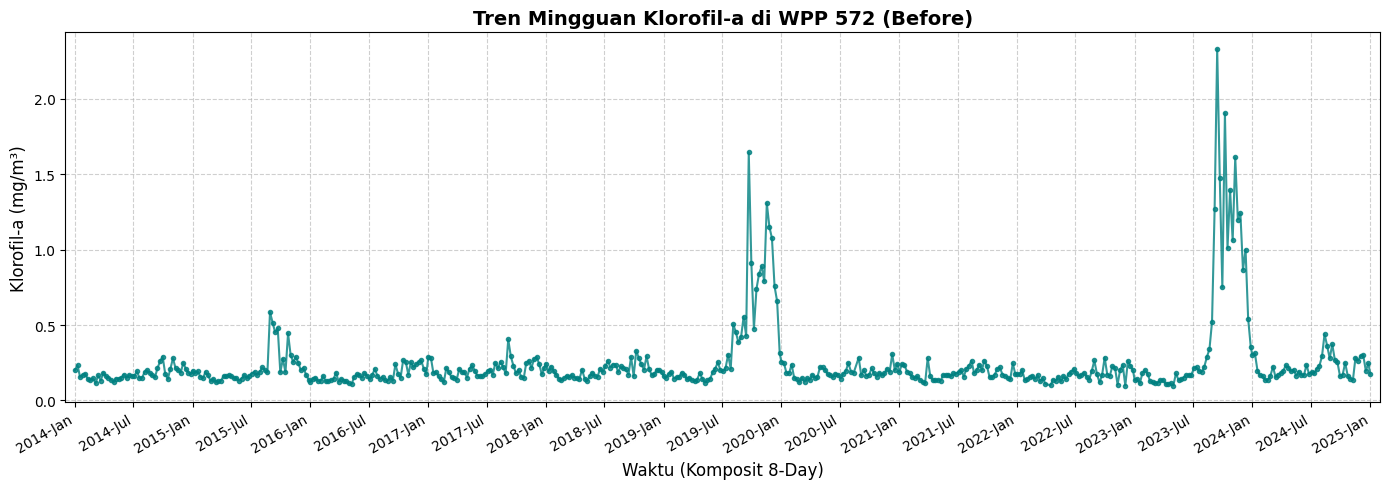

In [22]:
plot_tren_waktu(
    ds=ds_chl, 
    var_name='chlor_a', 
    judul='Tren Mingguan Klorofil-a di WPP 572 (Before)', 
    ylabel='Klorofil-a (mg/m³)', 
    warna='teal'
)

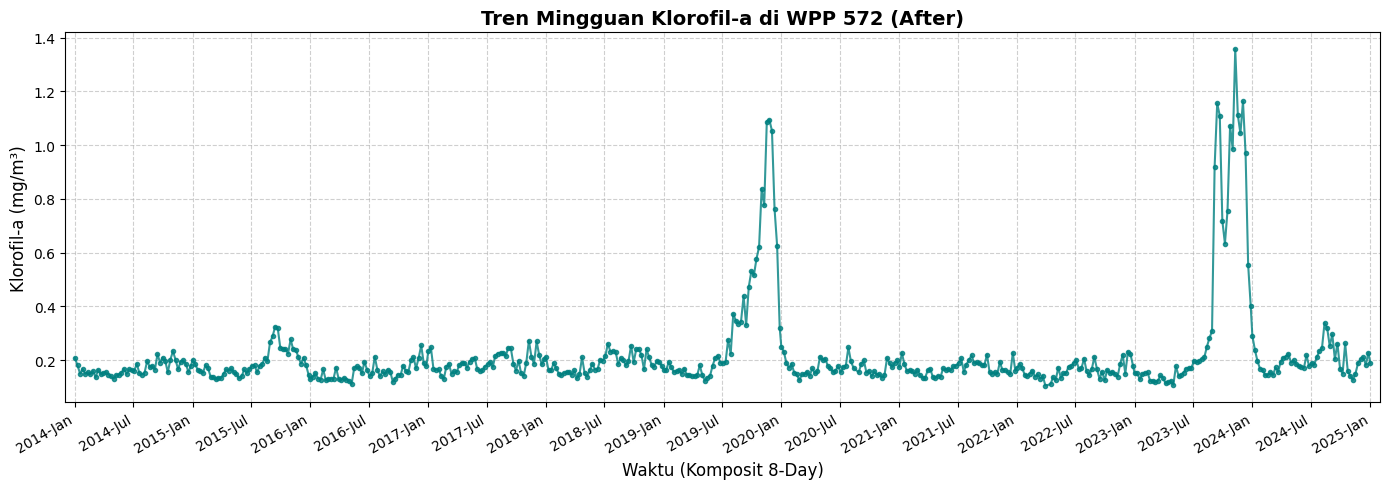

In [23]:
plot_tren_waktu(
    ds=ds_chl_clean, 
    var_name='chlor_a', 
    judul='Tren Mingguan Klorofil-a di WPP 572 (After)', 
    ylabel='Klorofil-a (mg/m³)', 
    warna='teal'
)

🔄 Menghitung rata-rata spasial area WPP per waktu untuk 'chlor_a'...
📅 Melakukan akumulasi tahunan menggunakan metode 'mean'...
📊 Menggambar Line Chart Tahunan...


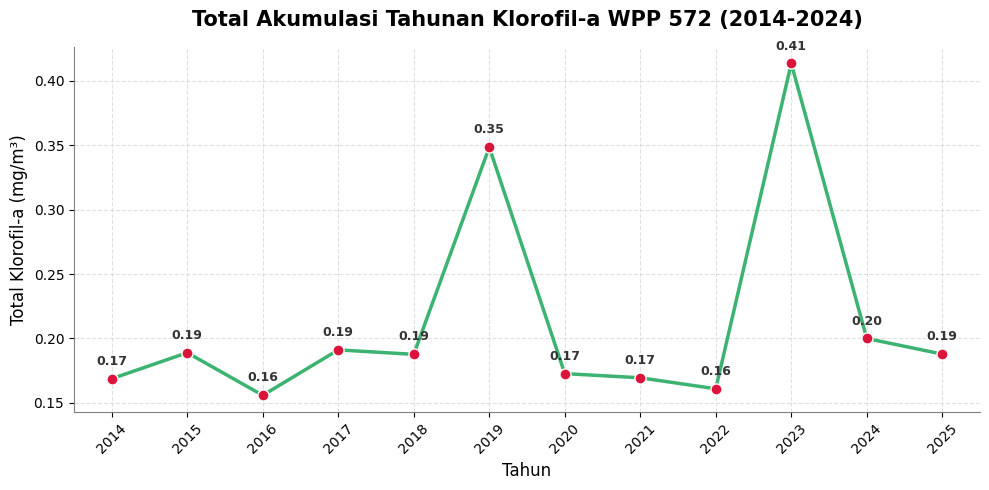

✅ Line Chart Tahunan berhasil dirender!



In [24]:
plot_line_chart_tahunan(
    ds=ds_chl_clean, 
    var_name='chlor_a', 
    mask_2d=mask_2d, 
    judul='Total Akumulasi Tahunan Klorofil-a WPP 572 (2014-2024)', 
    ylabel='Total Klorofil-a (mg/m³)', 
    warna_garis='mediumseagreen',
    metode='mean' # Menghitung total nilai sepanjang tahun
)

## Heatmap Monthly

🔄 Menghitung rata-rata klimatologi (2014-2024) untuk 'chlor_a'...
📊 Menggambar 12 plot heatmap...


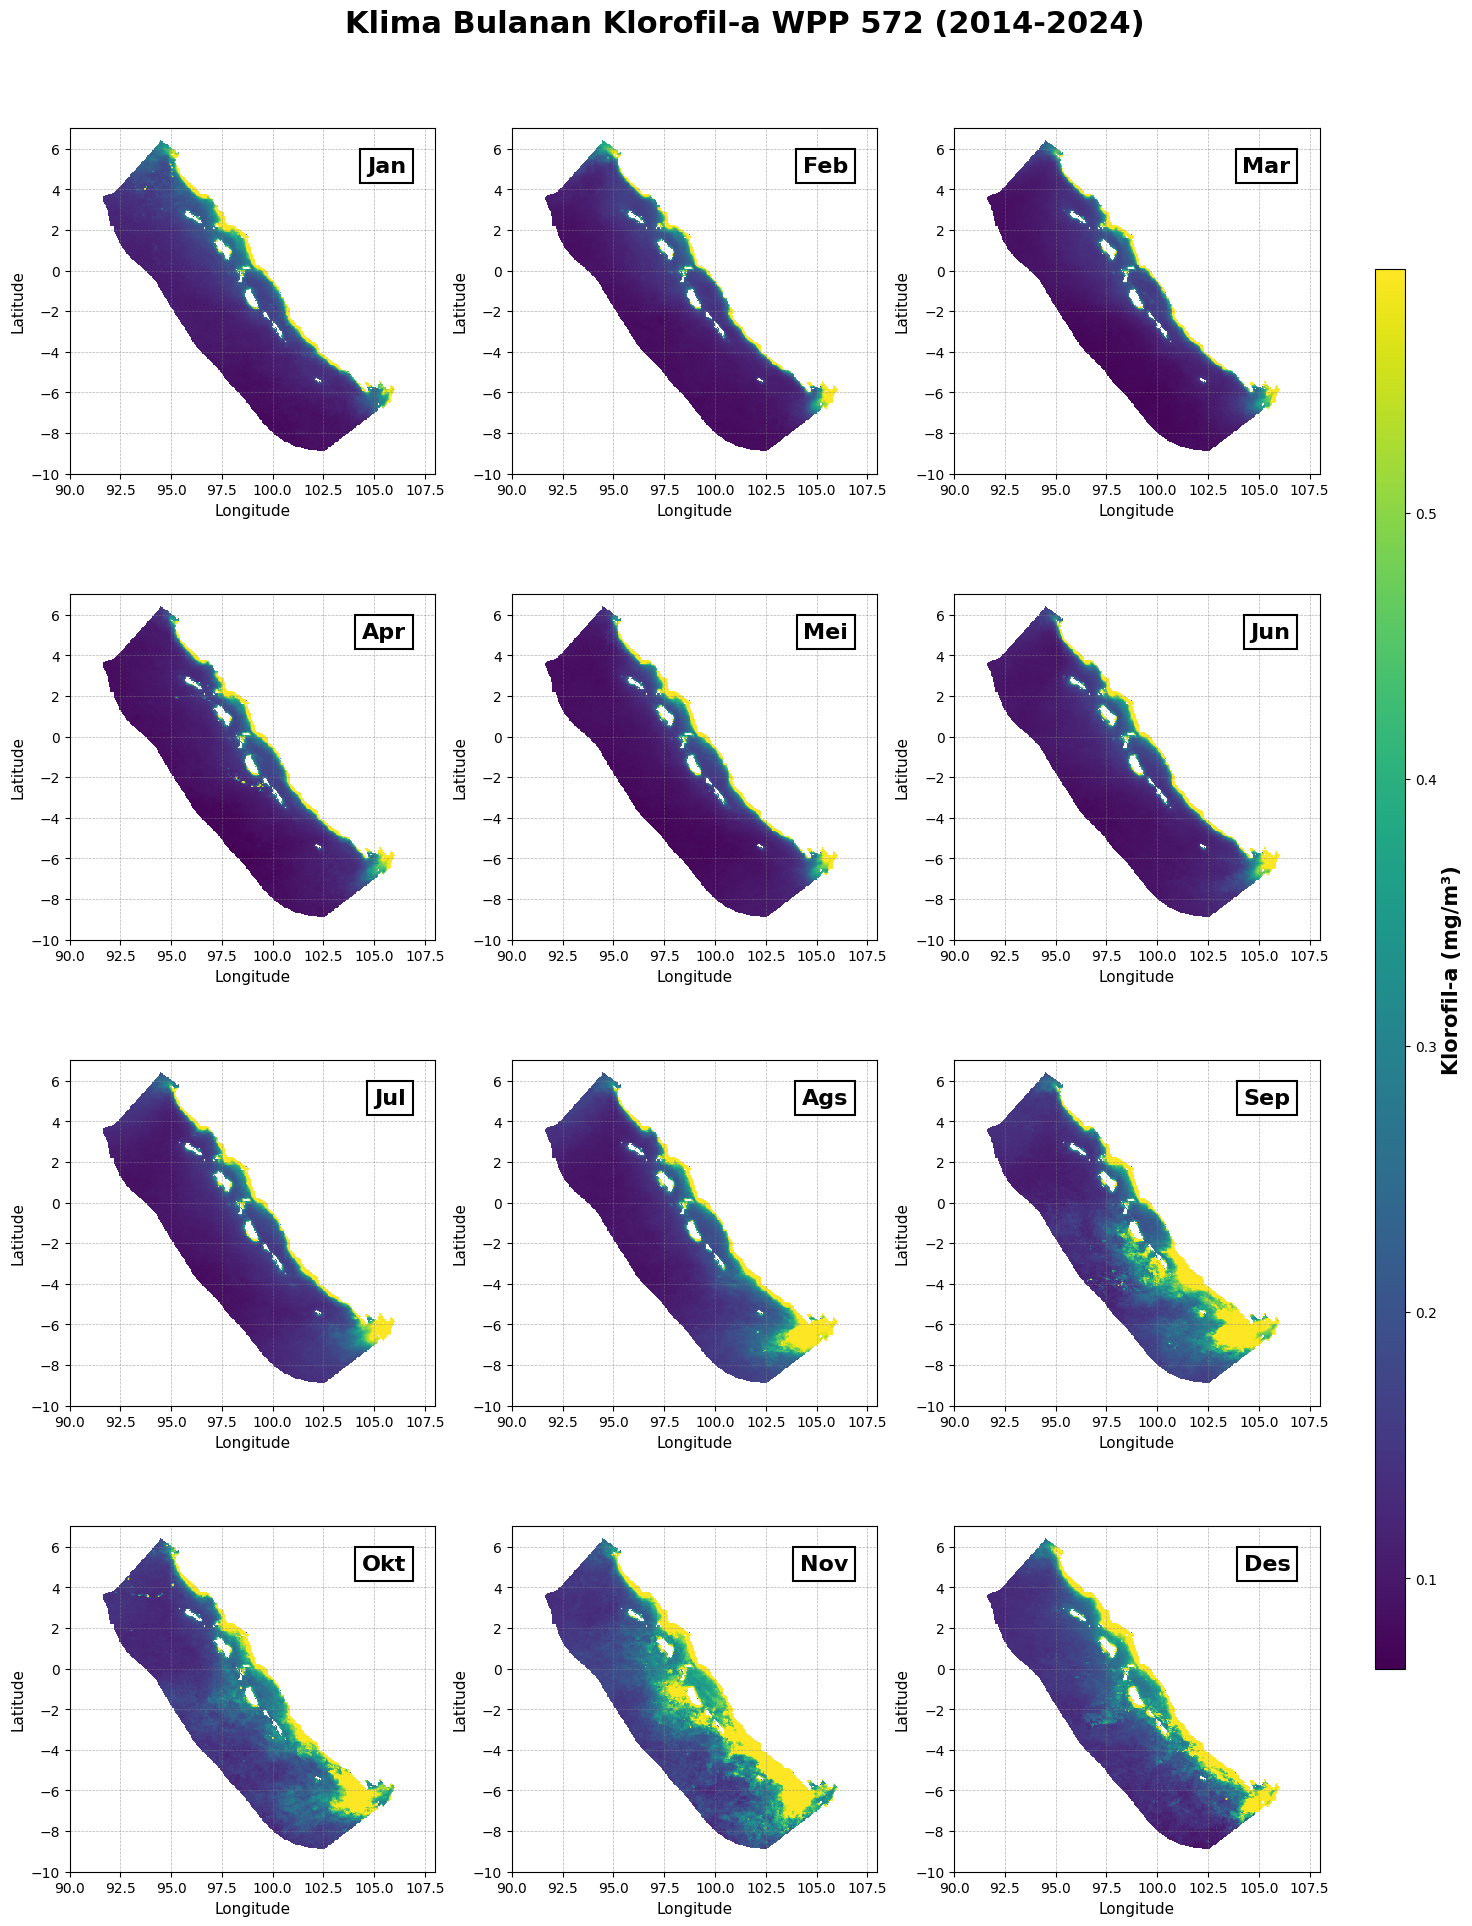

✅ Plot berhasil dirender!



In [25]:
plot_klimatologi_final(
    ds=ds_chl_clean, 
    var_name='chlor_a', 
    cbar_label='Klorofil-a (mg/m³)', 
    judul='Klima Bulanan Klorofil-a WPP 572 (2014-2024)',
    cmap_name='viridis',
    percentile_max=95  # Batasi outlier atas
)

## Distribusi Data

🔄 Mengekstrak seluruh piksel valid untuk 'chlor_a'...
📊 Menyiapkan visualisasi untuk 22,247,270 titik data...


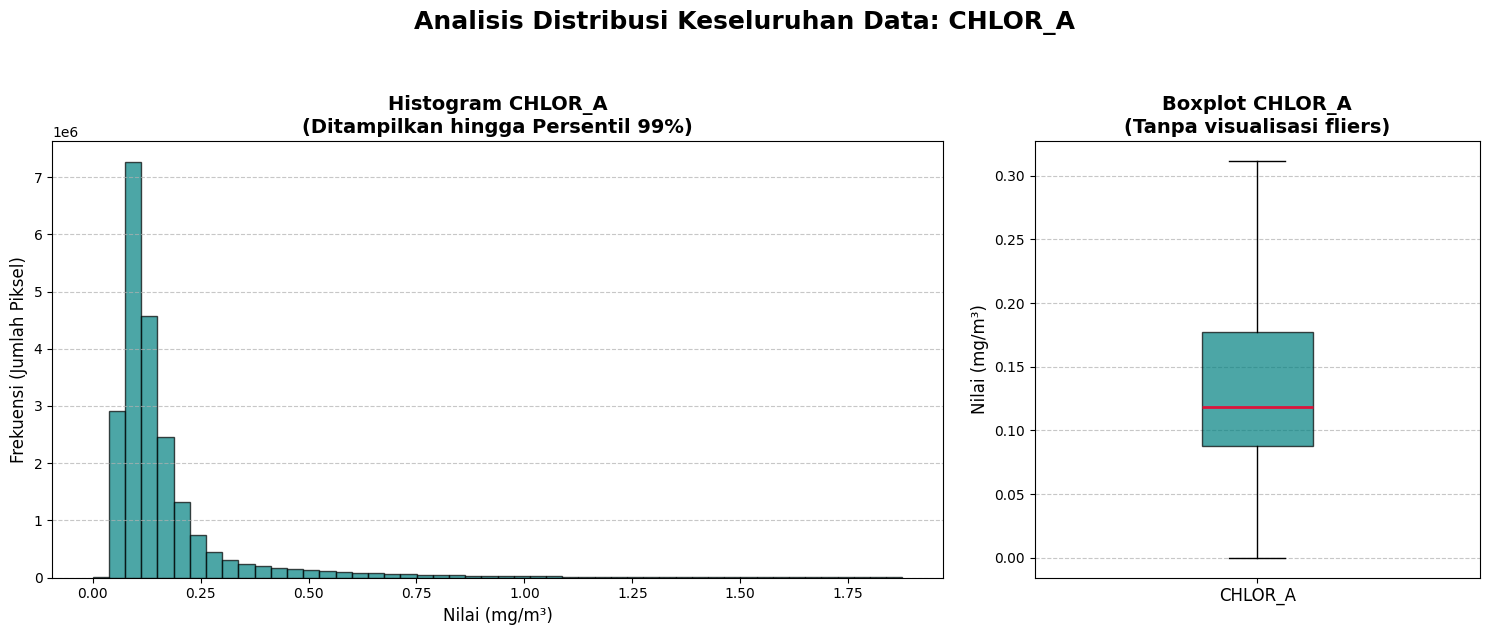

In [26]:
plot_distribusi_data(
    ds=ds_chl_clean, 
    var_name='chlor_a', 
    mask_2d=mask_2d, 
    warna='teal', 
    satuan='mg/m³'
)

🔄 Mengekstrak dan mengelompokkan piksel valid per bulan untuk 'chlor_a'...
📊 Menggambar Boxplot Distribusi Bulanan...


/tmp/ipykernel_16/806886026.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data_per_bulan, vert=True, patch_artist=True,


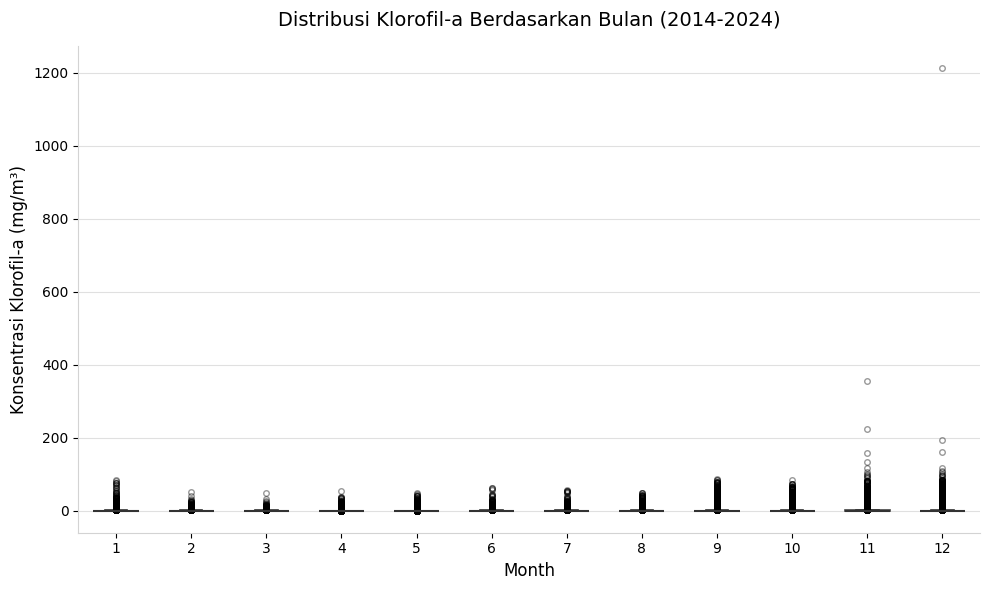

✅ Plot berhasil dirender!



In [27]:
plot_distribusi_bulanan(
    ds=ds_chl_clean, 
    var_name='chlor_a', 
    mask_2d=mask_2d, 
    judul='Distribusi Klorofil-a Berdasarkan Bulan (2014-2024)', 
    ylabel='Konsentrasi Klorofil-a (mg/m³)', 
    warna='mediumseagreen', 
    tampilkan_outlier=True
)

## ACF & PACF

--- Memulai Plotting ACF & PACF untuk chlor_a ---
Jumlah observasi time series : 505
Rata-rata                    : 0.214444
Standar deviasi              : 0.167505


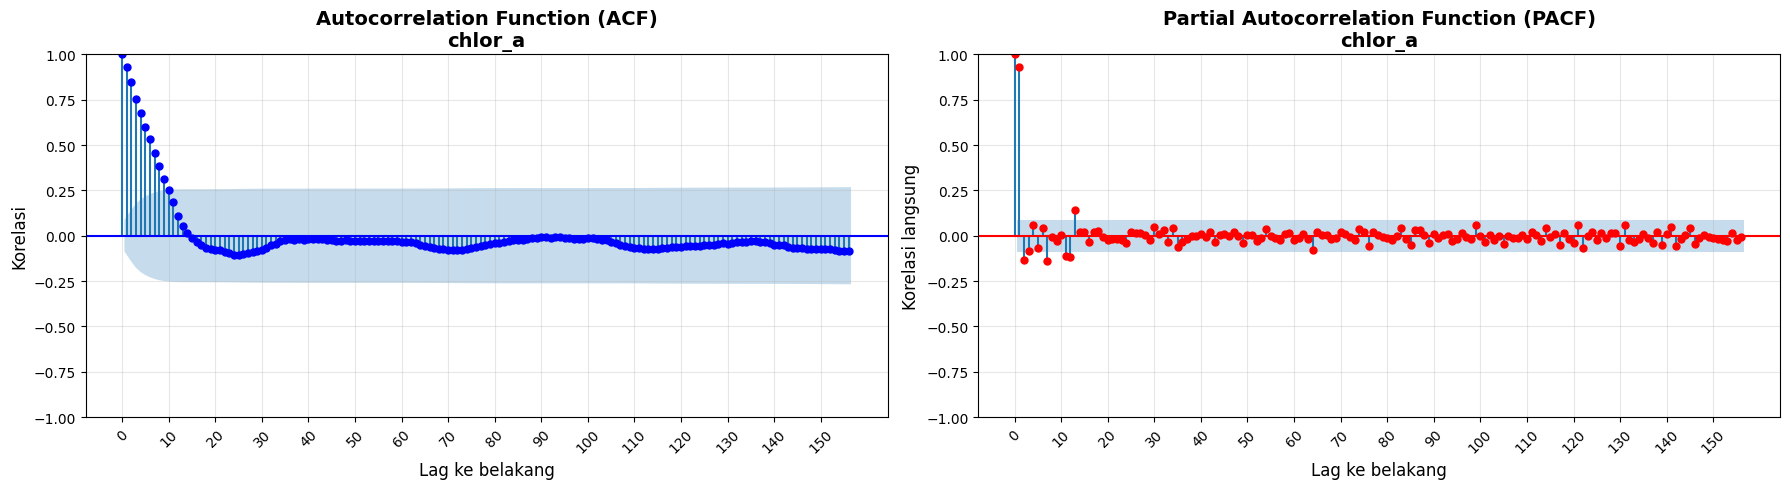

In [28]:
ts_chl = plot_acf_pacf_wpp(
    ds=ds_chl_clean,
    varname="chlor_a",
    nlags=156
)

## MissVal

In [29]:
df_miss_chl = pd.read_csv('/kaggle/input/notebooks/andreh19/3-1-3d-dineof/df_missval.csv')
df_miss_chl.head()

,week_index,time,total_valid,total_missing,percent_missing
0,1,2014-01-01,25817,18237,41.396922
1,2,2014-01-09,16167,27887,63.301857
2,3,2014-01-17,12176,31878,72.361193
3,4,2014-01-25,35208,8846,20.079902
4,5,2014-02-02,19158,24896,56.512462


In [30]:
summary_chl = summary_missing(
    df_miss_chl,
    nama_data="Klorofil-a"
)

RINGKASAN MISSING VALUE - Klorofil-a
Total observasi         : 22,247,270
Total valid             : 13,267,313
Total missing           : 8,979,957
Persen valid            : 59.64%
Persen missing          : 40.36%
----------------------------------------------------------------------
Total timestamp         : 505
Missing > 50%           : 175 (34.65%)
Missing > 75%           : 62 (12.28%)
Missing > 95%           : 7 (1.39%)


STATISTIK MISSING VALUE - Klorofil-a
Rata-rata missing : 40.36%
Minimum missing   : 0.36%
Maksimum missing  : 98.96%


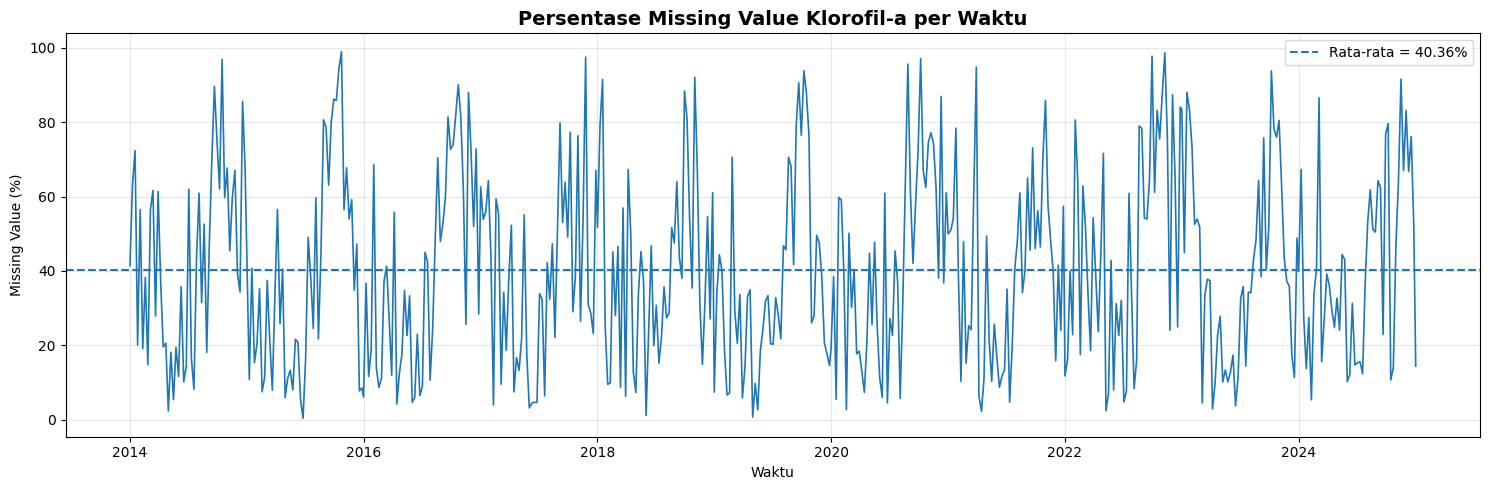

In [31]:
plot_missing_timeseries(
    df_miss_chl,
    nama_data="Klorofil-a"
)

/tmp/ipykernel_16/2128665563.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_plot = plt.cm.get_cmap(cmap).copy()


Figure tersimpan di: /kaggle/working/comparison_missing_vs_3ddineof_chl.png


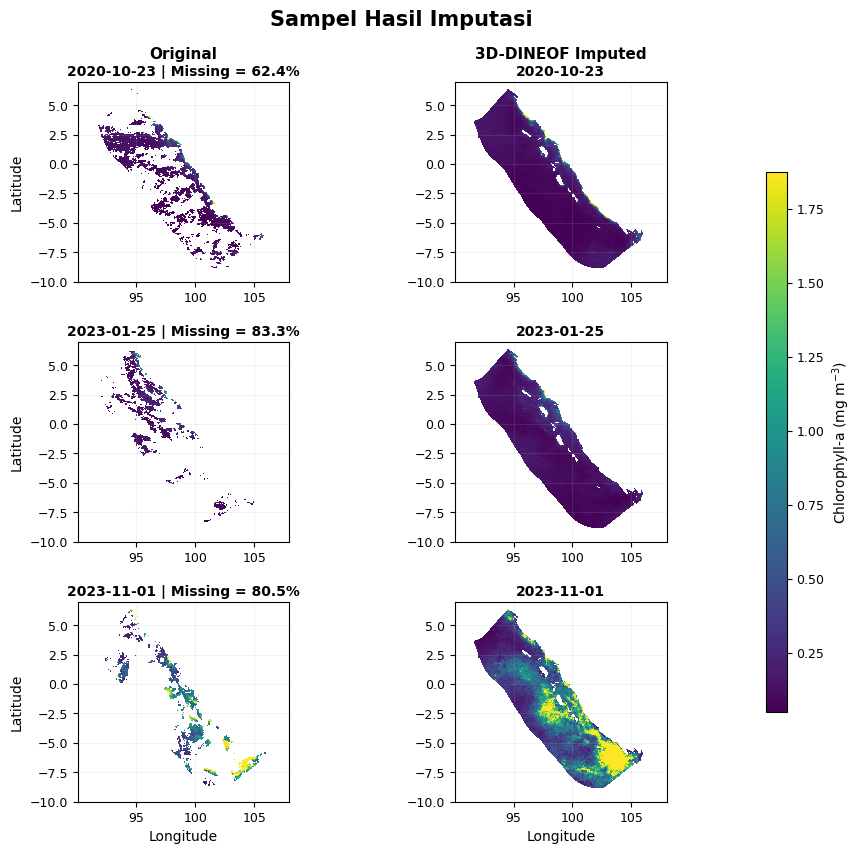

,week_index,time,total_valid,total_missing,percent_missing
0,313,2020-10-23,16554,27500,62.423389
1,416,2023-01-25,7367,36687,83.277341
2,451,2023-11-01,8598,35456,80.483044


In [32]:
sampel_chl = plot_random_missing_vs_imputed_final(
    ds_chl_asli=ds_chl,
    ds_chl_clean=ds_chl_clean,
    df_miss_chl=df_miss_chl,
    n_sample=3,
    min_missing=50,
    random_state=42,
    varname="chlor_a",
    save_path="/kaggle/working/comparison_missing_vs_3ddineof_chl.png"
)

sampel_chl

# SST

In [33]:
# data before missval
ds_sst = xr.open_dataset('/kaggle/input/notebooks/andreh19/9-sst-prepo/dsst_wpp572.nc')

# data after missval
ds_sst_clean = xr.open_dataset('/kaggle/input/notebooks/andreh19/10-1-3d-sst-missval/ds_wpp_sst_3d_clean.nc')

In [34]:
ds_sst_clean = ds_sst_clean.drop_vars("sst")
ds_sst_clean = ds_sst_clean.rename({"sst_3ddineof": "sst"})

In [35]:
ds_sst

<xarray.Dataset> Size: 700MB
Dimensions:   (time: 496, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time      (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat       (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon       (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    sst       (time, lat, lon) float32 350MB ...
    qual_sst  (time, lat, lon) float32 350MB ...
    palette   (time, rgb, eightbitcolor) uint8 381kB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.SST...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        99152
    data_minimum:                     24.244999
    data_maximum:                     35.745

In [36]:
ds_sst_clean

<xarray.Dataset> Size: 1GB
Dimensions:   (time: 496, lat: 408, lon: 432, rgb: 3, eightbitcolor: 256)
Coordinates:
  * time      (time) datetime64[ns] 4kB 2014-01-01 2014-01-09 ... 2025-01-01
  * lat       (lat) float32 2kB 6.979 6.938 6.896 6.854 ... -9.896 -9.938 -9.979
  * lon       (lon) float32 2kB 90.02 90.06 90.1 90.15 ... 107.9 107.9 108.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    qual_sst  (time, lat, lon) float32 350MB ...
    palette   (time, rgb, eightbitcolor) uint8 381kB ...
    sst       (time, lat, lon) float64 699MB ...
Attributes: (12/61)
    product_name:                     AQUA_MODIS.20140101_20140108.L3m.8D.SST...
    instrument:                       MODIS
    title:                            MODISA Level-3 Equidistant Cylindrical ...
    project:                          Ocean Biology Processing Group (NASA/GS...
    platform:                         Aqua
    source:                           satellite observations from MODIS-Aqua
    ...                               ...
    processing_level:                 L3 Mapped
    cdm_data_type:                    grid
    proj4_string:                     +proj=eqc +lat_ts=0 +lat_0=0 +x_0=0 +y_...
    data_bins:                        99152
    data_minimum:                     24.244999
    data_maximum:                     35.745

## Deskripsi Data2

In [37]:
# Cek data mentah
df_sst_mentah = deskripsi_data_wpp(ds_sst, 'sst', mask_2d)
display(df_sst_mentah)

Statistik,Rata-rata,Std Deviasi,Minimum,25% (Q1),Median,75% (Q3),Maximum,Range
Nilai_sst,29.886,1.307,19.525,29.184999,30.01,30.764999,37.445,17.92


In [38]:
# Cek data bersih (hasil DINEOF)
df_sst_bersih = deskripsi_data_wpp(ds_sst_clean, 'sst', mask_2d)
display(df_sst_bersih)

Statistik,Rata-rata,Std Deviasi,Minimum,25% (Q1),Median,75% (Q3),Maximum,Range
Nilai_sst,29.795,1.251,19.525,29.082,29.86,30.64,37.445,17.92


## Cek Anomali2

In [39]:
investigasi(
    ds_asli=ds_sst,       # Dataset mentah Anda (sebelum diisi)
    ds_clean=ds_sst_clean,    # Dataset bersih hasil DINEOF
    var_name='sst',
    mask_2d=mask_2d,
    batas_ekstrem=38   # Nilai batas yang Anda inginkan
)

🔍 --- MEMULAI INVESTIGASI ANOMALI 'sst' (> 38) ---
Total piksel valid WPP    : 21,850,784 piksel
Jumlah piksel ekstrem     : 0 piksel
Persentase piksel ekstrem : 0.000000 %

✅ Data sangat sehat. Tidak ditemukan outlier ekstrem pada rentang waktu mana pun.
------------------------------------------------------------


## Linechart2

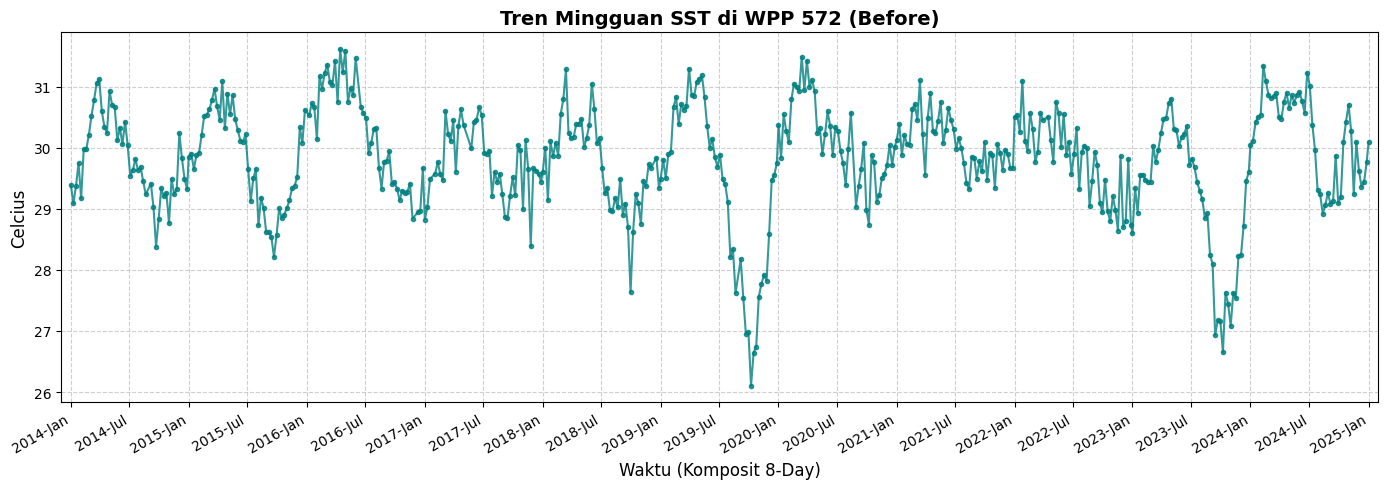

In [40]:
plot_tren_waktu(
    ds=ds_sst, 
    var_name='sst', 
    judul='Tren Mingguan SST di WPP 572 (Before)', 
    ylabel='Celcius', 
    warna='teal'
)

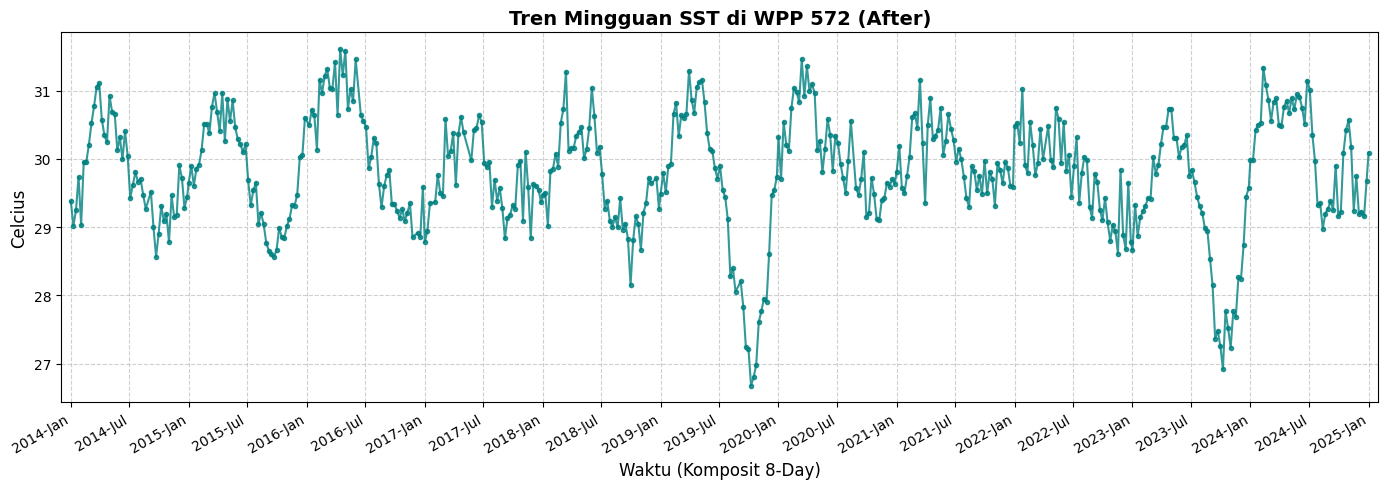

In [41]:
plot_tren_waktu(
    ds=ds_sst_clean, 
    var_name='sst', 
    judul='Tren Mingguan SST di WPP 572 (After)', 
    ylabel='Celcius', 
    warna='teal'
)

🔄 Menghitung rata-rata spasial area WPP per waktu untuk 'sst'...
📅 Melakukan akumulasi tahunan menggunakan metode 'mean'...
📊 Menggambar Line Chart Tahunan...


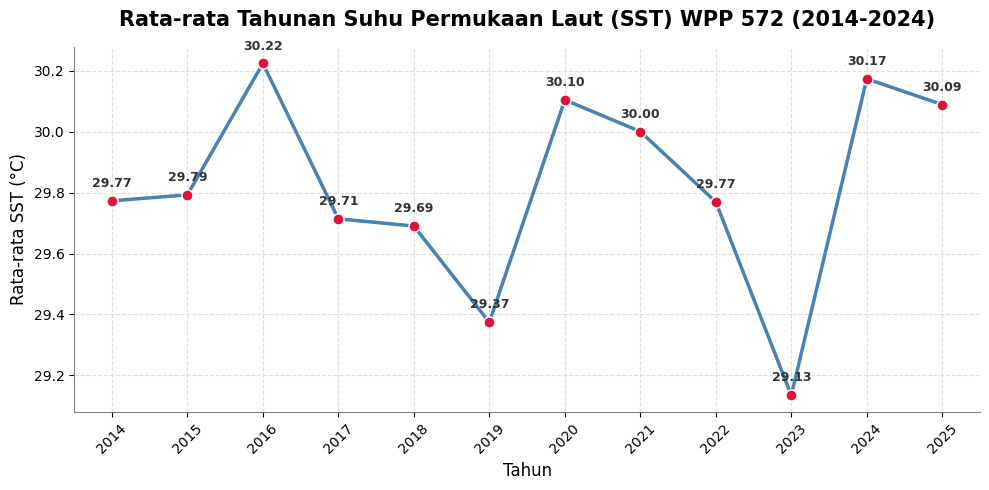

✅ Line Chart Tahunan berhasil dirender!



In [42]:
plot_line_chart_tahunan(
    ds=ds_sst_clean, 
    var_name='sst', 
    mask_2d=mask_2d, 
    judul='Rata-rata Tahunan Suhu Permukaan Laut (SST) WPP 572 (2014-2024)', 
    ylabel='Rata-rata SST (°C)', 
    warna_garis='steelblue',
    metode='mean' # Menghitung rata-rata nilai sepanjang tahun
)

## Heatmap Monthly2

🔄 Menghitung rata-rata klimatologi (2014-2024) untuk 'sst'...
📊 Menggambar 12 plot heatmap...


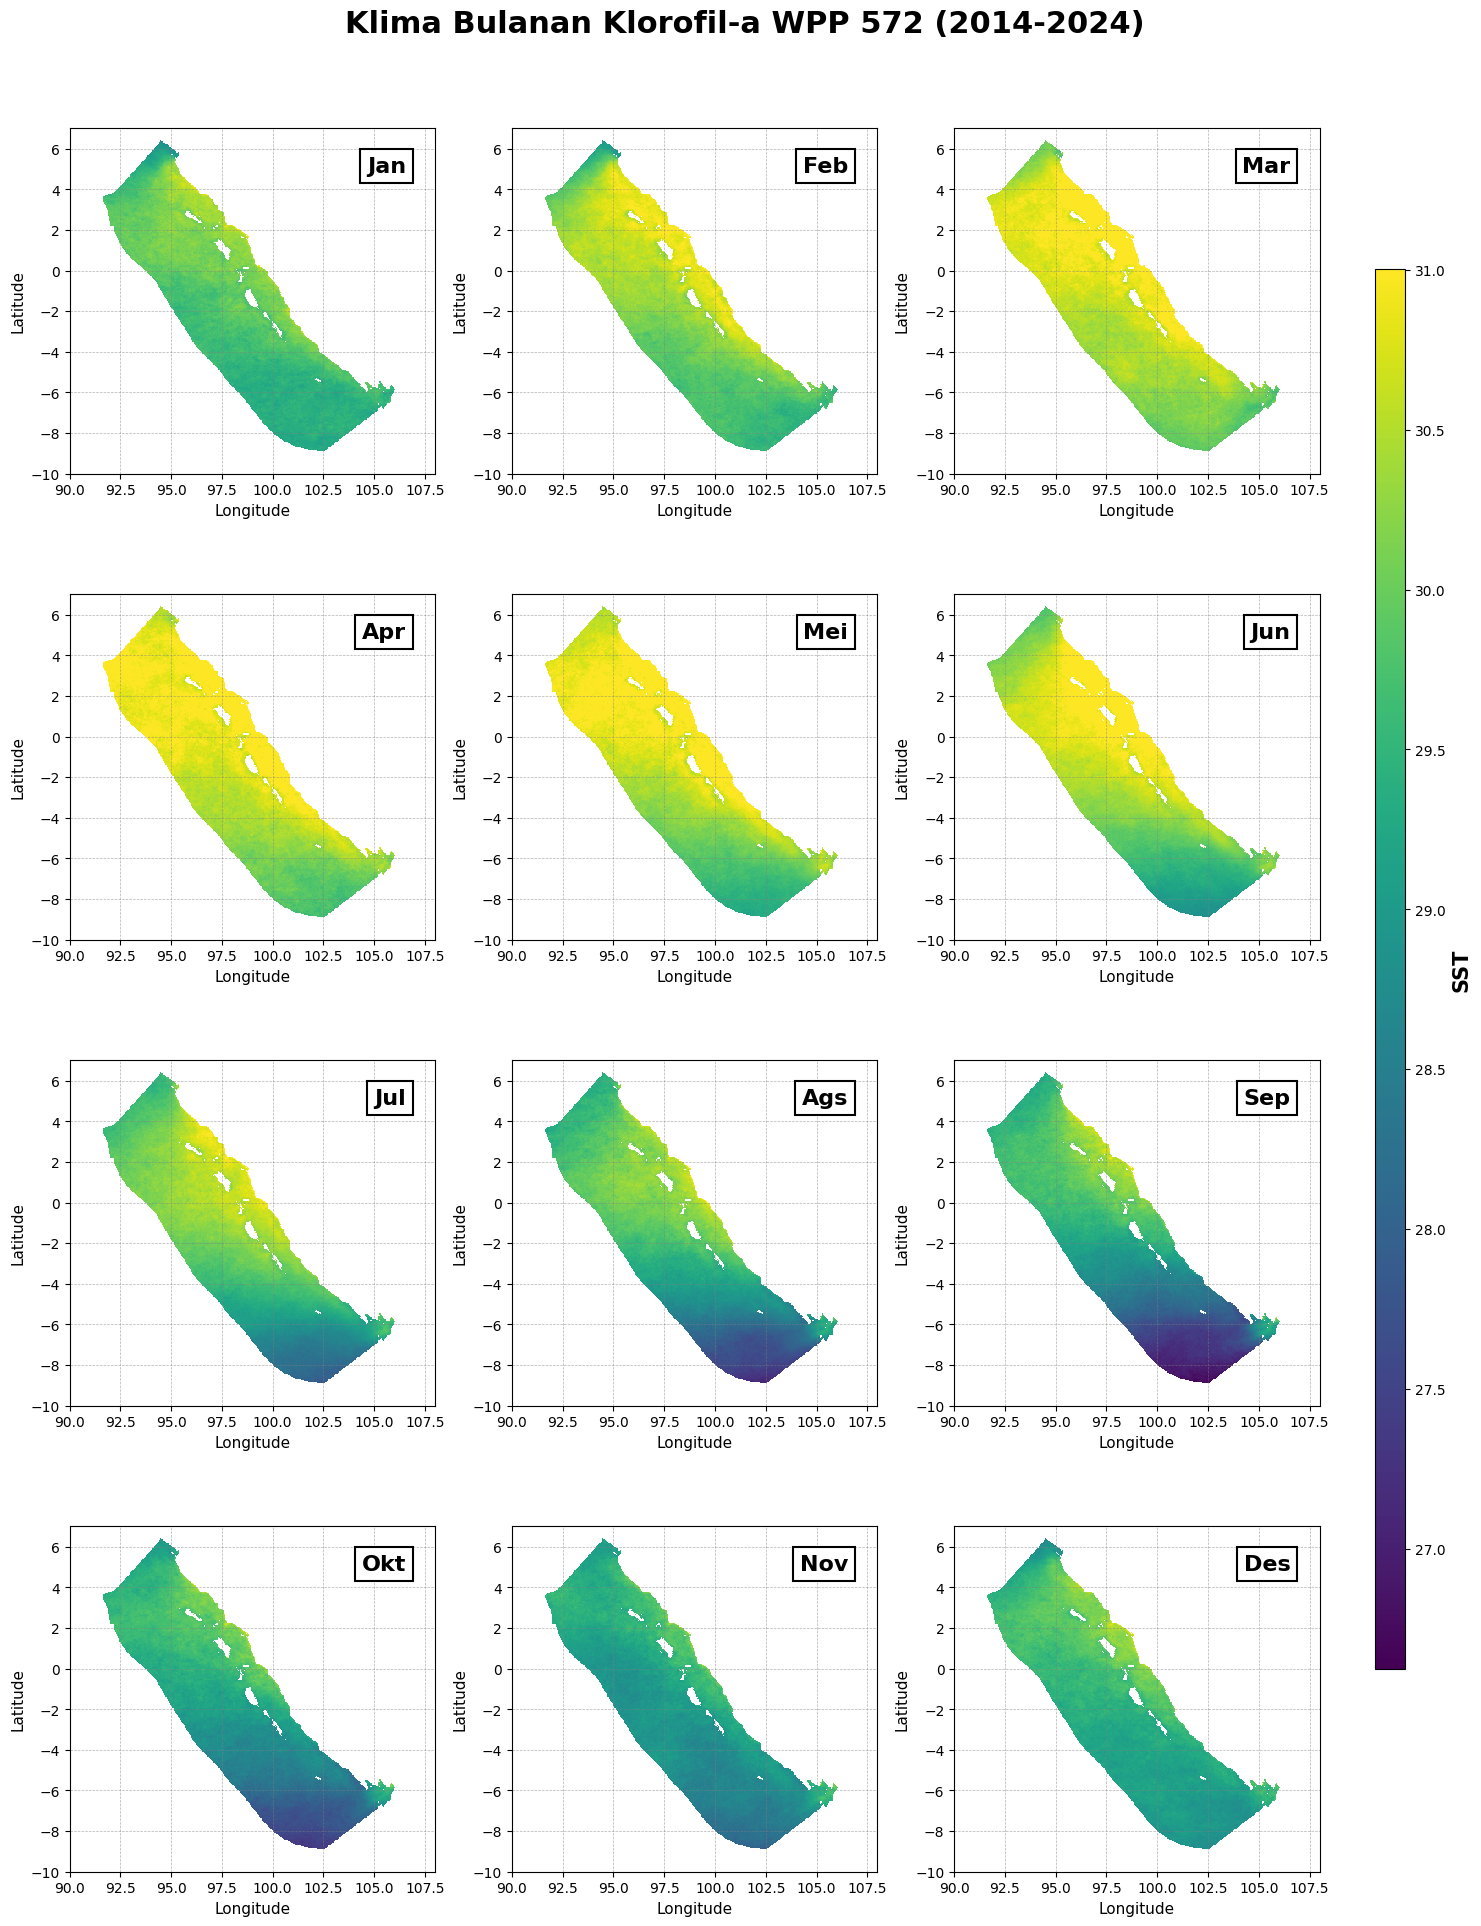

✅ Plot berhasil dirender!



In [43]:
plot_klimatologi_final(
    ds=ds_sst_clean, 
    var_name='sst', 
    cbar_label='SST', 
    judul='Klima Bulanan Klorofil-a WPP 572 (2014-2024)',
    cmap_name='viridis',
    percentile_max=95  # Batasi outlier atas
)

## Distribusi Data2

🔄 Mengekstrak seluruh piksel valid untuk 'sst'...
📊 Menyiapkan visualisasi untuk 21,850,784 titik data...


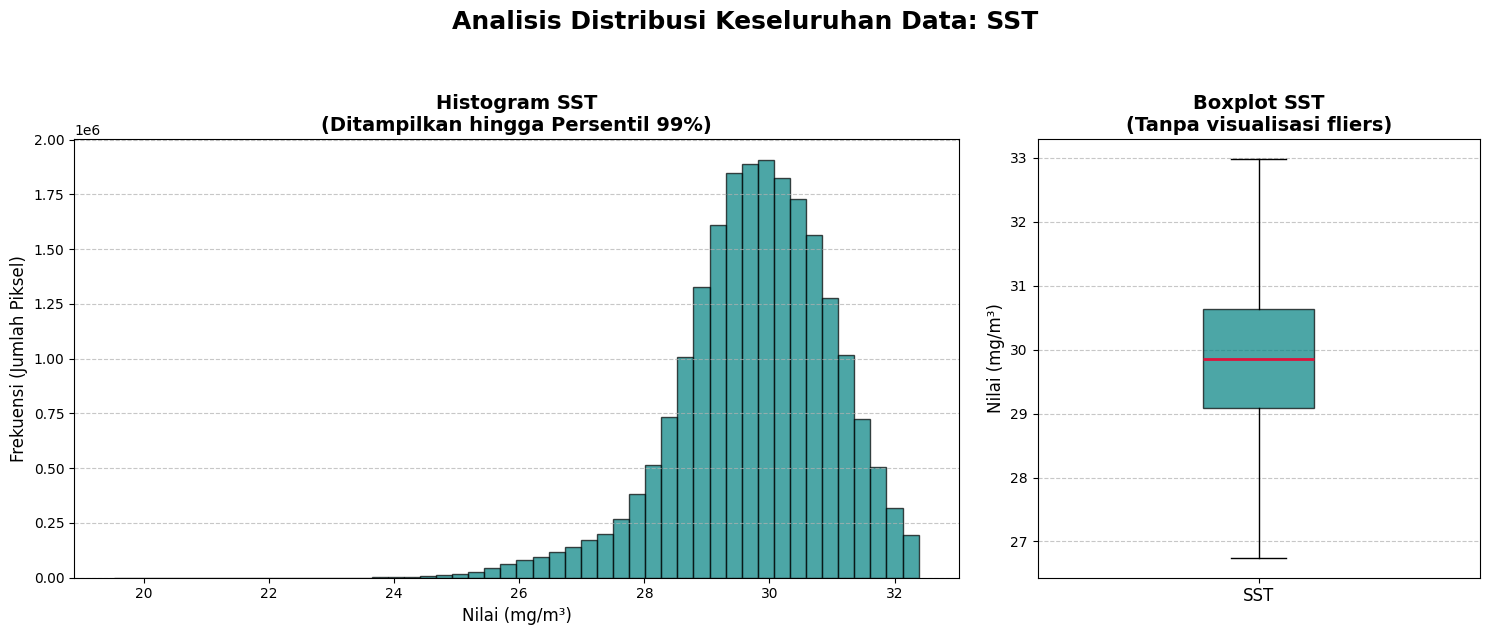

In [44]:
plot_distribusi_data(
    ds=ds_sst_clean, 
    var_name='sst', 
    mask_2d=mask_2d, 
    warna='teal', 
    satuan='mg/m³'
)

🔄 Mengekstrak dan mengelompokkan piksel valid per bulan untuk 'sst'...
📊 Menggambar Boxplot Distribusi Bulanan...


/tmp/ipykernel_16/806886026.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(data_per_bulan, vert=True, patch_artist=True,


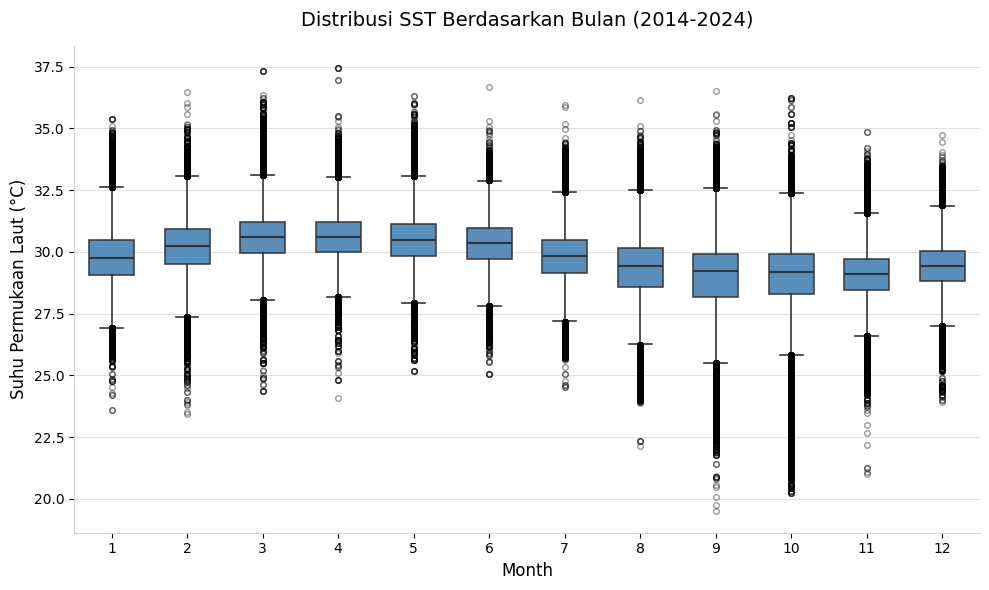

✅ Plot berhasil dirender!



In [45]:
plot_distribusi_bulanan(
    ds=ds_sst_clean, 
    var_name='sst', 
    mask_2d=mask_2d, 
    judul='Distribusi SST Berdasarkan Bulan (2014-2024)',   # Masukkan parameter judul
    ylabel='Suhu Permukaan Laut (°C)',                      # Masukkan parameter label Y
    warna='steelblue', 
    tampilkan_outlier=True
)

## ACF & PACF 2

--- Memulai Plotting ACF & PACF untuk sst ---
Jumlah observasi time series : 496
Rata-rata                    : 29.794601
Standar deviasi              : 0.839606


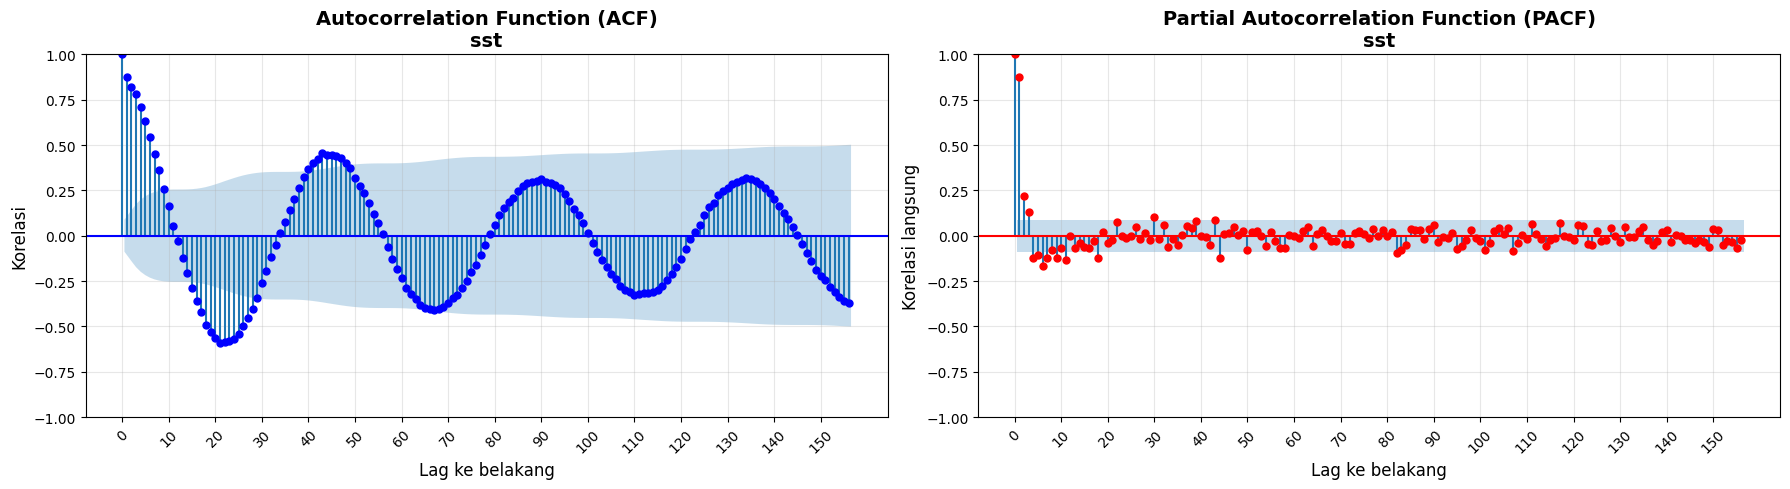

In [46]:
ts_sst = plot_acf_pacf_wpp(
    ds=ds_sst_clean,
    varname="sst",
    nlags=156
)

## MissVal2

In [47]:
df_miss_sst = pd.read_csv('/kaggle/input/notebooks/andreh19/10-1-3d-sst-missval/df_missval_sst.csv')
df_miss_sst.head()

,week_index,time,total_valid,total_missing,percent_missing
0,1,2014-01-01,31221,12833,29.130158
1,2,2014-01-09,31206,12848,29.164208
2,3,2014-01-17,25435,18619,42.264040
3,4,2014-01-25,43425,629,1.427793
4,5,2014-02-02,30023,14031,31.849548


In [48]:
summary_sst = summary_missing(
    df_miss_sst,
    nama_data="SST")

RINGKASAN MISSING VALUE - SST
Total observasi         : 21,850,784
Total valid             : 17,340,091
Total missing           : 4,510,693
Persen valid            : 79.36%
Persen missing          : 20.64%
----------------------------------------------------------------------
Total timestamp         : 496
Missing > 50%           : 60 (12.10%)
Missing > 75%           : 14 (2.82%)
Missing > 95%           : 1 (0.20%)


STATISTIK MISSING VALUE - SST
Rata-rata missing : 20.64%
Minimum missing   : 0.01%
Maksimum missing  : 95.27%


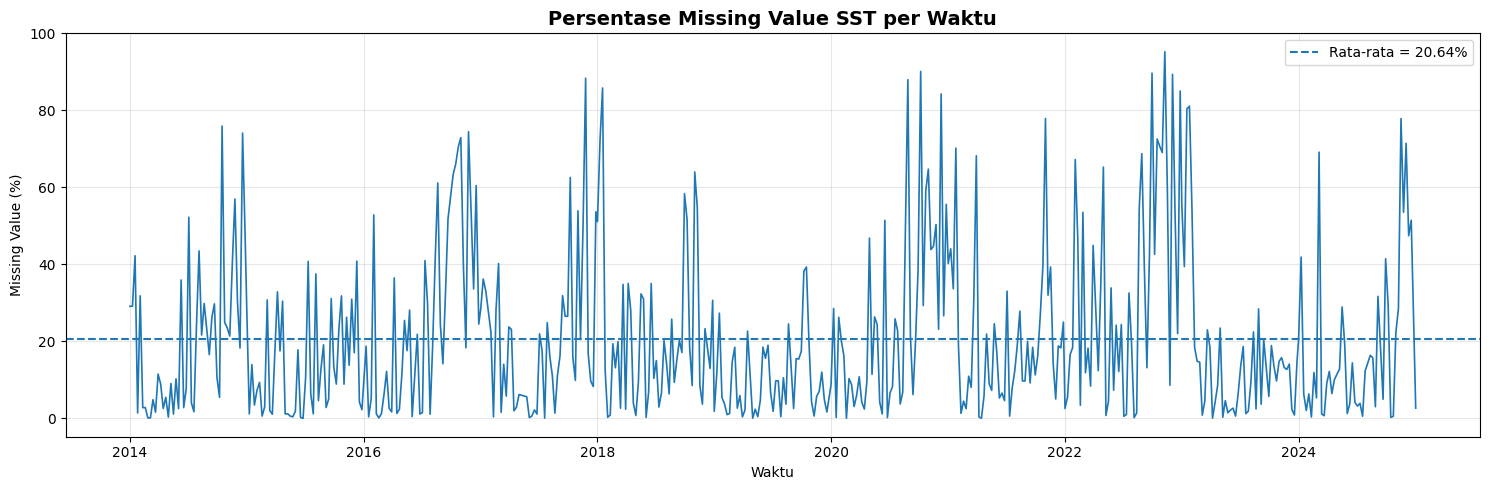

In [49]:
plot_missing_timeseries(
    df_miss_sst,
    nama_data="SST"
)

/tmp/ipykernel_16/2128665563.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_plot = plt.cm.get_cmap(cmap).copy()


Figure tersimpan di: /kaggle/working/comparison_missing_vs_3ddineof_sst.png


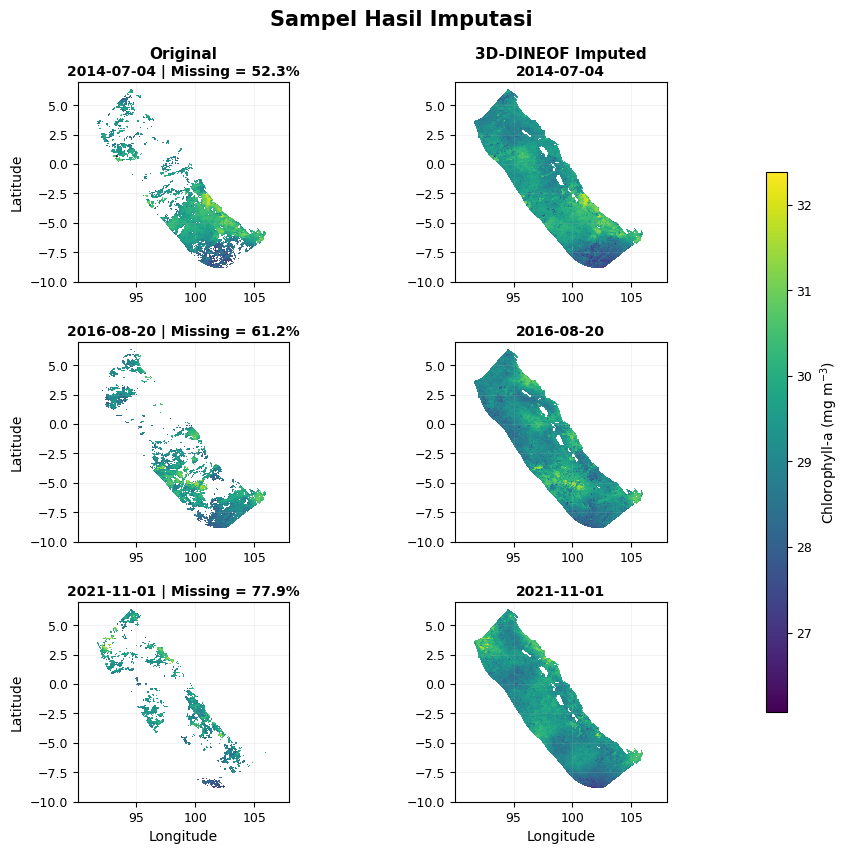

,week_index,time,total_valid,total_missing,percent_missing
0,24,2014-07-04,21029,23025,52.265402
1,119,2016-08-20,17114,26940,61.152222
2,351,2021-11-01,9727,34327,77.920280


In [50]:
sampel_sst = plot_random_missing_vs_imputed_final(
    ds_chl_asli=ds_sst,
    ds_chl_clean=ds_sst_clean,
    df_miss_chl=df_miss_sst,
    n_sample=3,
    min_missing=50,
    random_state=42,
    varname="sst",
    save_path="/kaggle/working/comparison_missing_vs_3ddineof_sst.png"
)

sampel_sst

# Scatterplot

🔄 Langkah 1: Menghitung rata-rata spasial WPP 572 per waktu...
📊 Ukuran waktu awal  -> Chl-a: 505 | SST: 496
✂️ Langkah 2: Menyinkronkan tanggal (membuang waktu yang tidak berpasangan)...
🎯 Ukuran waktu akhir -> Chl-a: 496 | SST: 496
📈 Langkah 3: Menggambar Scatter Plot & Garis Regresi...


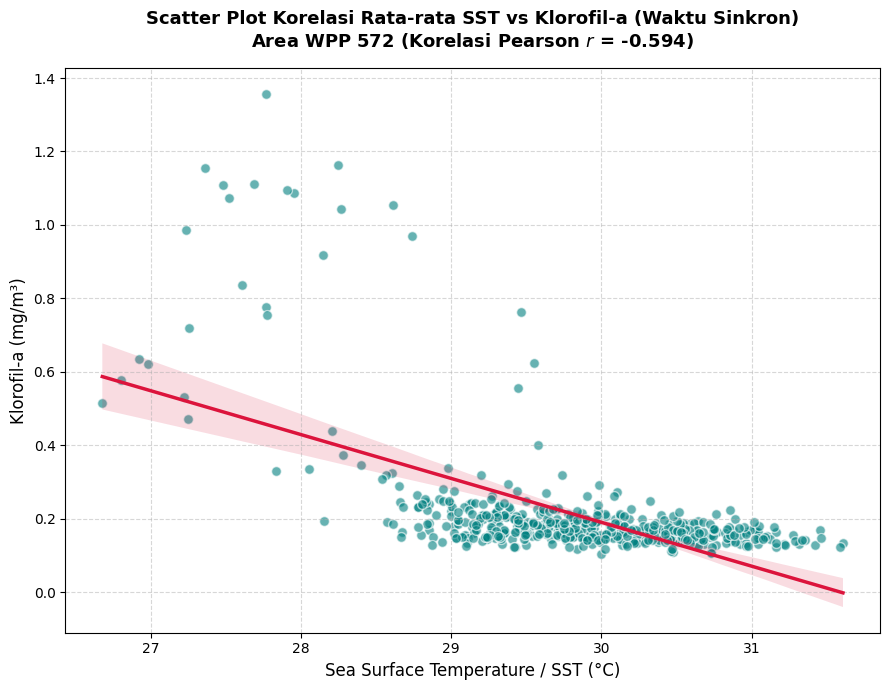

In [51]:
plot_scatter_sst_chl_sinkron(
    ds_chl=ds_chl_clean, 
    ds_sst=ds_sst_clean, 
    var_chl='chlor_a', 
    var_sst='sst', 
    mask_2d=mask_2d
)